# Online Retail II — Advanced Analytics
## Market Basket Analysis · Product Recommendation Engine · Cancellation Intelligence

**Dataset:** UCI Online Retail II (Kaggle) — ~1M transactions, UK-based e-commerce, 2009–2011  
**Analytical Framework:**

| # | Module | Method | Business Question |
|---|--------|--------|-------------------|
| 1 | Data Audit & Cleaning | EDA + Quality Checks | What does the data actually contain, and what needs fixing? |
| 2 | Market Basket Analysis | Apriori (manual) | Which products travel together in the same basket? |
| 3 | Recommendation Engine | Item-based Collaborative Filtering | What should we recommend to each customer next? |
| 4 | Cancellation Intelligence | Statistical profiling + root cause | Why do orders get cancelled, and who cancels? |

> **How to read this notebook:** Each section begins with a *Why we do this* rationale box, works through the analysis, and ends with *So what?* business implications. You should be able to hand this directly to a stakeholder and they will follow the story.


## 0 · Setup & Dependencies

In [1]:
# ── Install & imports ─────────────────────────────────────────────────────
# Uncomment the line below if running for the first time (e.g., Kaggle / Colab)
# !pip install kagglehub --quiet

import warnings
warnings.filterwarnings("ignore")

import os
import re
from itertools import combinations

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns

import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Consistent visual style throughout
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})
PALETTE = ["#4e79a7", "#59a14f", "#f28e2b", "#e15759",
           "#76b7b2", "#edc948", "#b07aa1", "#ff9da7"]

print("Libraries loaded ✓")


Libraries loaded ✓


## 1 · Data Loading

We download the dataset directly from Kaggle using `kagglehub`.  
The raw file is a single CSV (`online_retail_II.csv`) with ~1 million rows.


In [2]:
import kagglehub

path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")
print("Dataset path:", path)
print("Files:", os.listdir(path))


100%|██████████| 14.5M/14.5M [00:00<00:00, 123MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/mashlyn/online-retail-ii-uci/versions/3
Files: ['online_retail_II.csv']


In [3]:
df_raw = pd.read_csv(f"{path}/online_retail_II.csv", encoding="utf-8-sig")

# Standardise column names immediately — strip whitespace, replace spaces
df_raw.columns = df_raw.columns.str.strip().str.replace(" ", "_")

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print()
print(df_raw.dtypes)
df_raw.head(3)


Shape: 1,067,371 rows × 8 columns

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer_ID    float64
Country         object
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom


## 2 · Data Audit & Quality Assessment

> **Why this matters:** Cleaning decisions are not administrative—they define the population of transactions your analysis represents. Every dropped row is a business choice; we document each one.

### 2.1 Missing Values & Basic Profile


In [4]:
# ── Comprehensive data profile ────────────────────────────────────────────
def data_profile(df):
    profile = pd.DataFrame({
        "dtype":       df.dtypes,
        "non_null":    df.notnull().sum(),
        "null_count":  df.isnull().sum(),
        "null_pct":    (df.isnull().mean() * 100).round(2),
        "n_unique":    df.nunique(),
        "sample":      [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })
    return profile

print("=== DATA PROFILE ===")
print(data_profile(df_raw).to_string())


=== DATA PROFILE ===
               dtype  non_null  null_count  null_pct  n_unique                               sample
Invoice       object   1067371           0      0.00     53628                               489434
StockCode     object   1067371           0      0.00      5305                                85048
Description   object   1062989        4382      0.41      5698  15CM CHRISTMAS GLASS BALL 20 LIGHTS
Quantity       int64   1067371           0      0.00      1057                                   12
InvoiceDate   object   1067371           0      0.00     47635                  2009-12-01 07:45:00
Price        float64   1067371           0      0.00      2807                                 6.95
Customer_ID  float64    824364      243007     22.77      5942                              13085.0
Country       object   1067371           0      0.00        43                       United Kingdom


In [5]:
# ── Numeric range sanity check ────────────────────────────────────────────
print("Quantity — descriptive stats:")
print(df_raw["Quantity"].describe().to_string())
print()
print("Price — descriptive stats:")
print(df_raw["Price"].describe().to_string())


Quantity — descriptive stats:
count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04

Price — descriptive stats:
count    1.067371e+06
mean     4.649388e+00
std      1.235531e+02
min     -5.359436e+04
25%      1.250000e+00
50%      2.100000e+00
75%      4.150000e+00
max      3.897000e+04


### 2.2 Key Data Quality Findings

| Issue | Rows Affected | Interpretation | Decision |
|-------|--------------|----------------|----------|
| `Customer_ID` missing | ~243k (23%) | Anonymous / guest checkout | **Keep for basket analysis** (we group by Invoice); **drop for CF engine** (need identity) |
| `Description` missing | ~4.4k | Stock code exists, name not recorded | Drop — basket analysis needs product names |
| `Quantity ≤ 0` | varies | Returns, adjustments, samples | Drop — not real forward purchases |
| `Price ≤ 0` | varies | Internal transfers, free samples | Drop — not market transactions |
| Invoice starts with `C` | ~9.5k | Explicit cancellation flag | **Analyse separately** then drop from basket/CF |
| `Country ≠ United Kingdom` | ~8% | Export orders, B2B abroad | Keep for most analyses; filter to UK for basket (homogenous behaviour) |

> **Note on the 23% anonymous customers:** This is actually common in B2B wholesale — many accounts order by phone or via account number without a website login. The CF engine gracefully handles this by only using identifiable customers; basket analysis is unaffected.


In [6]:
# ── Extract cancellations BEFORE cleaning (for Section 4 analysis) ─────────
cancelled_raw = df_raw[df_raw["Invoice"].astype(str).str.startswith("C")].copy()
print(f"Cancellation records: {len(cancelled_raw):,}")
print(f"Unique cancelled invoices: {cancelled_raw['Invoice'].nunique():,}")
print(f"Est. revenue at risk: £{(cancelled_raw['Quantity'].abs() * cancelled_raw['Price']).sum():,.0f}")


Cancellation records: 19,494
Unique cancelled invoices: 8,292
Est. revenue at risk: £1,527,415


In [7]:
# ── Apply all cleaning steps with audit trail ─────────────────────────────
df = df_raw.copy()
audit = []

def drop_filter(df, mask, reason):
    n = mask.sum()
    df_out = df[~mask]
    audit.append({"Step": reason, "Rows removed": n, "Rows remaining": len(df_out)})
    return df_out

# Step 1: Cancelled invoices
df = drop_filter(df, df["Invoice"].astype(str).str.startswith("C"), "Cancelled invoices (Invoice starts with C)")

# Step 2: Negative / zero quantity
df = drop_filter(df, df["Quantity"] <= 0, "Non-positive Quantity (returns / adjustments)")

# Step 3: Negative / zero price
df = drop_filter(df, df["Price"] <= 0, "Non-positive Price (samples / internal transfers)")

# Step 4: Missing description
df = drop_filter(df, df["Description"].isnull(), "Missing Description")

# Step 5: Strip whitespace from Description (prevents duplicate product names)
df["Description"] = df["Description"].str.strip().str.upper()

# Step 6: Parse InvoiceDate as datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Step 7: Derive revenue column
df["Revenue"] = df["Quantity"] * df["Price"]

# ── Audit summary ──────────────────────────────────────────────────────────
print("=== CLEANING AUDIT TRAIL ===\n")
print(pd.DataFrame(audit).to_string(index=False))
print(f"\nFinal dataset: {len(df):,} rows ({100*len(df)/len(df_raw):.1f}% of raw)")


=== CLEANING AUDIT TRAIL ===

                                             Step  Rows removed  Rows remaining
       Cancelled invoices (Invoice starts with C)         19494         1047877
    Non-positive Quantity (returns / adjustments)          3457         1044420
Non-positive Price (samples / internal transfers)          2750         1041670
                              Missing Description             0         1041670

Final dataset: 1,041,670 rows (97.6% of raw)


## 3 · Exploratory Data Analysis

> **Goal:** Understand the *character* of this business before we mine patterns. Who are the customers? What do they buy? When? How much?


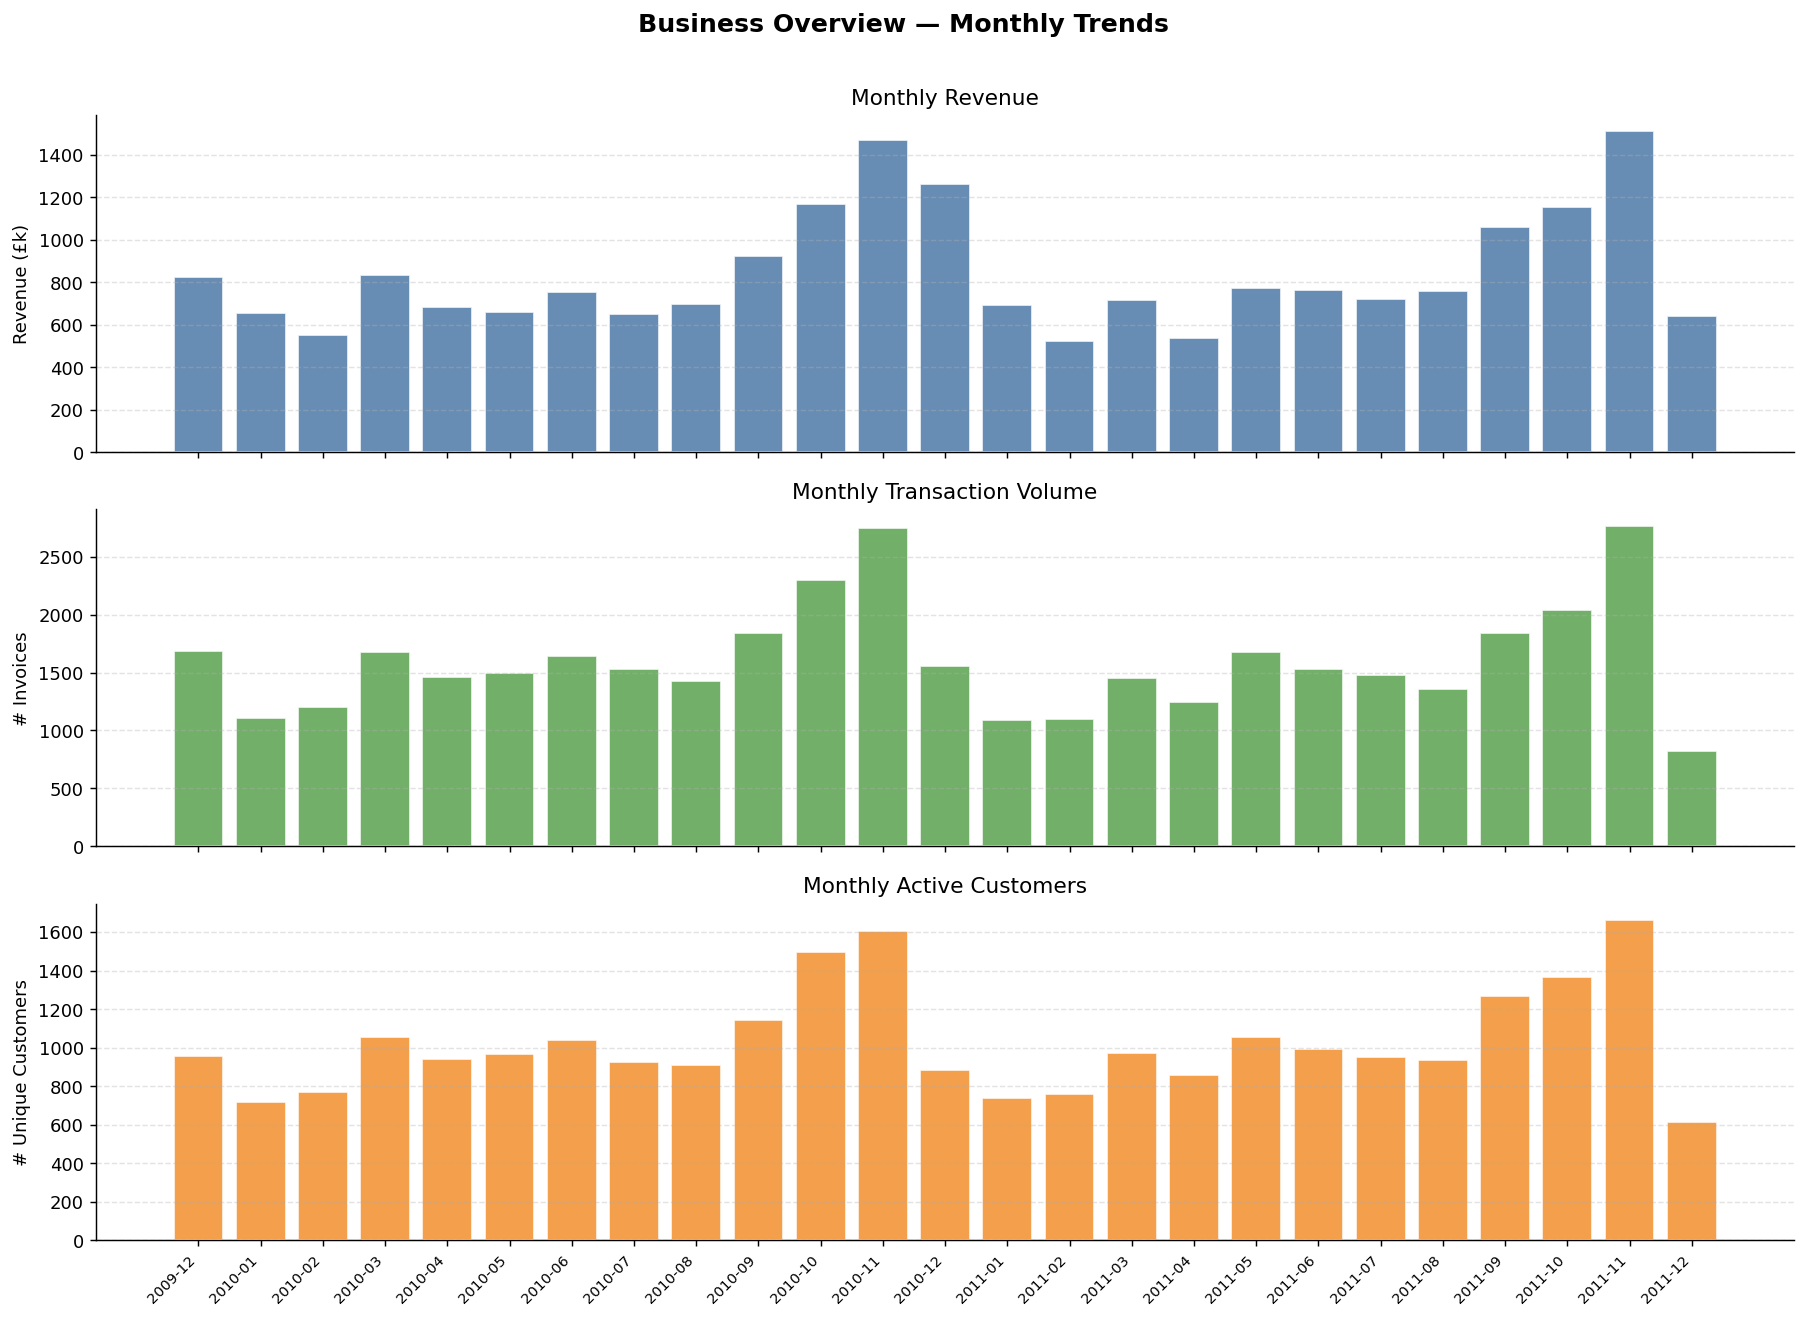


▶ Note the clear seasonal spike around Oct–Nov each year — this is a gift-ware retailer.
   The Q4 uplift should inform when promotions and bundles are deployed.


In [8]:
# ── Temporal overview ─────────────────────────────────────────────────────
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("YearMonth").agg(
    Transactions=("Invoice", "nunique"),
    Revenue=("Revenue", "sum"),
    Customers=("Customer_ID", "nunique"),
).reset_index()
monthly["YearMonth_str"] = monthly["YearMonth"].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Business Overview — Monthly Trends", fontsize=14, fontweight="bold", y=1.01)

axes[0].bar(monthly["YearMonth_str"], monthly["Revenue"] / 1e3,
            color=PALETTE[0], alpha=0.85, edgecolor="white")
axes[0].set_ylabel("Revenue (£k)")
axes[0].set_title("Monthly Revenue")

axes[1].bar(monthly["YearMonth_str"], monthly["Transactions"],
            color=PALETTE[1], alpha=0.85, edgecolor="white")
axes[1].set_ylabel("# Invoices")
axes[1].set_title("Monthly Transaction Volume")

axes[2].bar(monthly["YearMonth_str"], monthly["Customers"],
            color=PALETTE[2], alpha=0.85, edgecolor="white")
axes[2].set_ylabel("# Unique Customers")
axes[2].set_title("Monthly Active Customers")

for ax in axes:
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("eda_monthly_trends.png", bbox_inches="tight")
plt.show()
print("\n▶ Note the clear seasonal spike around Oct–Nov each year — this is a gift-ware retailer.")
print("   The Q4 uplift should inform when promotions and bundles are deployed.")


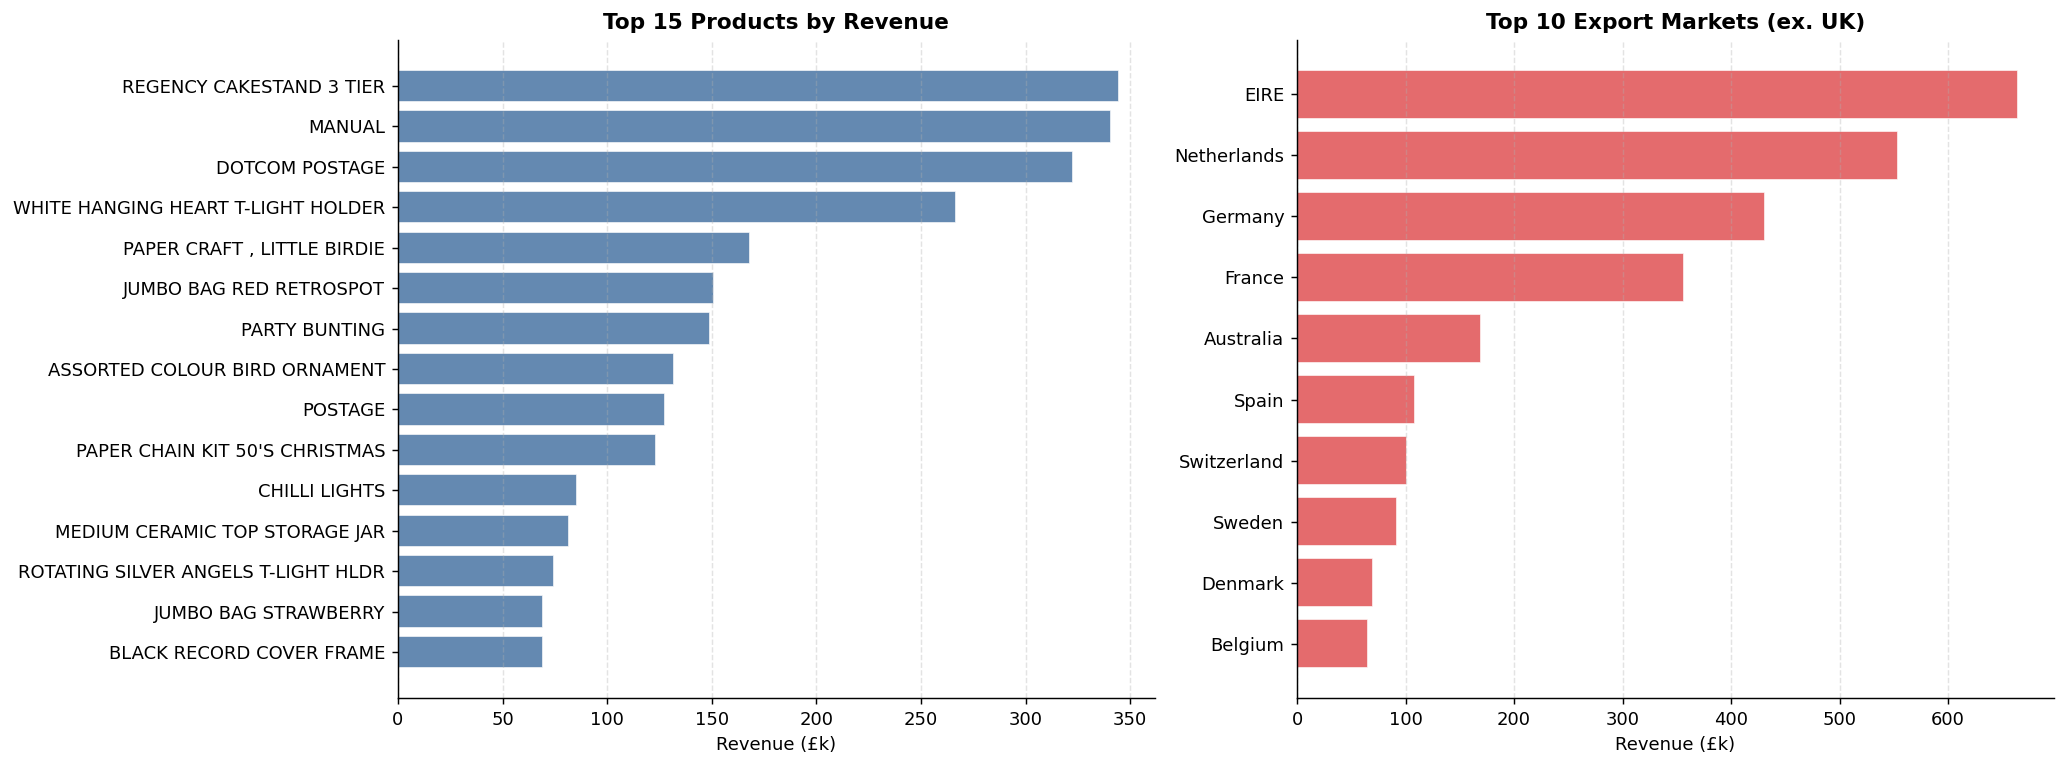

In [9]:
# ── Top products & countries ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 products by revenue
top_prod = (df.groupby("Description")["Revenue"]
              .sum()
              .sort_values(ascending=False)
              .head(15))
axes[0].barh(top_prod.index[::-1], top_prod.values[::-1] / 1e3,
             color=PALETTE[0], edgecolor="white", alpha=0.88)
axes[0].set_xlabel("Revenue (£k)")
axes[0].set_title("Top 15 Products by Revenue", fontweight="bold")
axes[0].grid(True, axis="x", linestyle="--", alpha=0.35)

# Top 10 countries by revenue (ex UK for scale)
top_ctry = (df[df["Country"] != "United Kingdom"]
              .groupby("Country")["Revenue"]
              .sum()
              .sort_values(ascending=False)
              .head(10))
axes[1].barh(top_ctry.index[::-1], top_ctry.values[::-1] / 1e3,
             color=PALETTE[3], edgecolor="white", alpha=0.88)
axes[1].set_xlabel("Revenue (£k)")
axes[1].set_title("Top 10 Export Markets (ex. UK)", fontweight="bold")
axes[1].grid(True, axis="x", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("eda_top_products_countries.png", bbox_inches="tight")
plt.show()


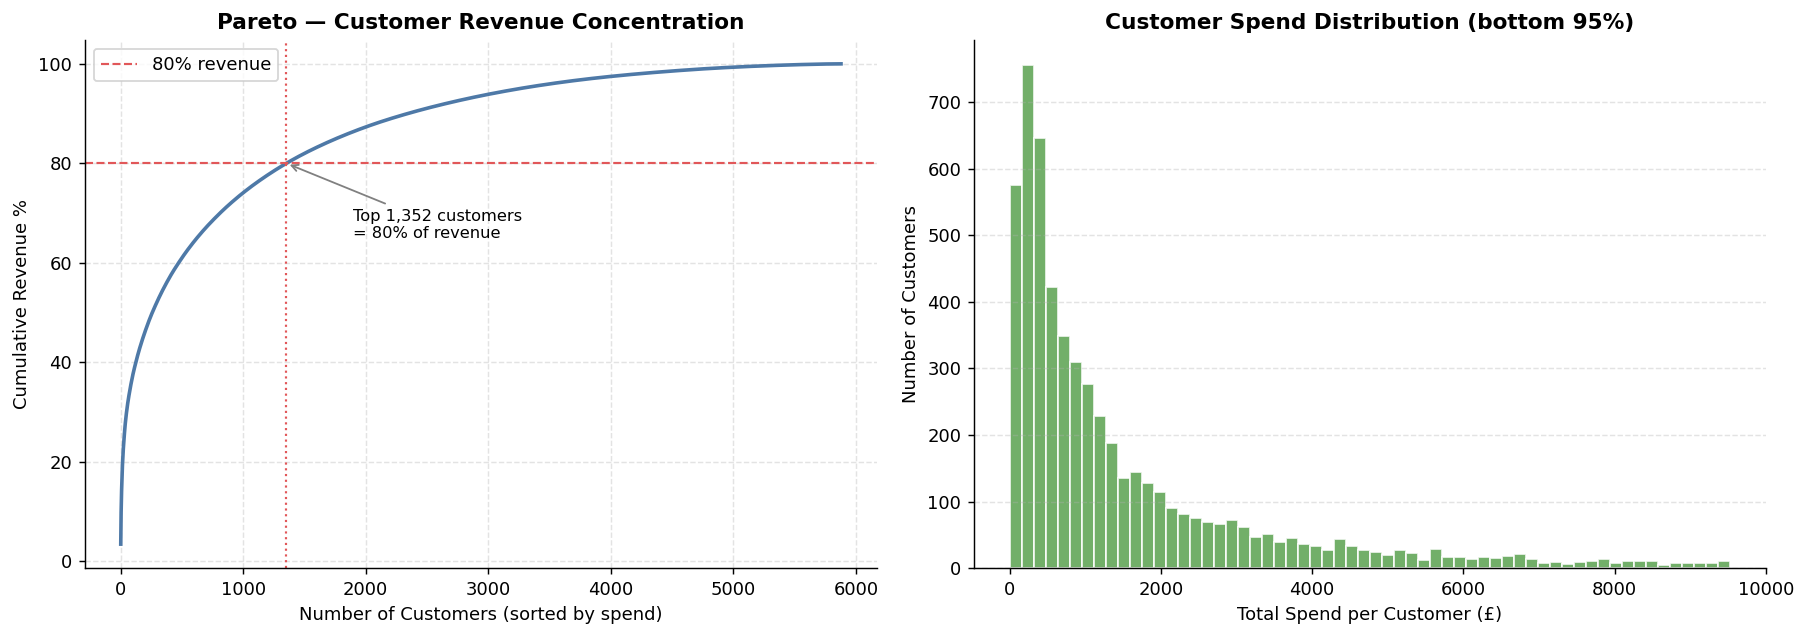


▶ Pareto finding: top 1,352 customers (23.0% of base) drive 80% of revenue.
   This has direct implications for tiered loyalty strategy and retention investment.


In [10]:
# ── Customer spend distribution (Pareto analysis) ─────────────────────────
cust_rev = (df.dropna(subset=["Customer_ID"])
              .groupby("Customer_ID")["Revenue"]
              .sum()
              .sort_values(ascending=False))

cumsum_pct = cust_rev.cumsum() / cust_rev.sum() * 100
n_for_80 = (cumsum_pct <= 80).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumsum_pct) + 1), cumsum_pct,
             color=PALETTE[0], linewidth=2)
axes[0].axhline(80, color=PALETTE[3], linestyle="--", linewidth=1.2, label="80% revenue")
axes[0].axvline(n_for_80, color=PALETTE[3], linestyle=":", linewidth=1.2)
axes[0].set_xlabel("Number of Customers (sorted by spend)")
axes[0].set_ylabel("Cumulative Revenue %")
axes[0].set_title("Pareto — Customer Revenue Concentration", fontweight="bold")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].annotate(f"Top {n_for_80:,} customers\n= 80% of revenue",
                 xy=(n_for_80, 80), xytext=(n_for_80 * 1.4, 65),
                 arrowprops=dict(arrowstyle="->", color="grey"), fontsize=9)

# Spend histogram (log scale for legibility)
axes[1].hist(cust_rev[cust_rev < cust_rev.quantile(0.95)], bins=60,
             color=PALETTE[1], edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Total Spend per Customer (£)")
axes[1].set_ylabel("Number of Customers")
axes[1].set_title("Customer Spend Distribution (bottom 95%)", fontweight="bold")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("eda_pareto.png", bbox_inches="tight")
plt.show()
print(f"\n▶ Pareto finding: top {n_for_80:,} customers ({100*n_for_80/len(cust_rev):.1f}% of base) drive 80% of revenue.")
print("   This has direct implications for tiered loyalty strategy and retention investment.")


Basket size summary (unique items per invoice):
count    40077.000000
mean        24.847618
std         42.132546
min          1.000000
25%          6.000000
50%         15.000000
75%         28.000000
max       1108.000000

Median basket size  : 15 unique items
Median basket value : £304.31
Mean  basket value  : £523.31
Top 1% basket value : £4542.06


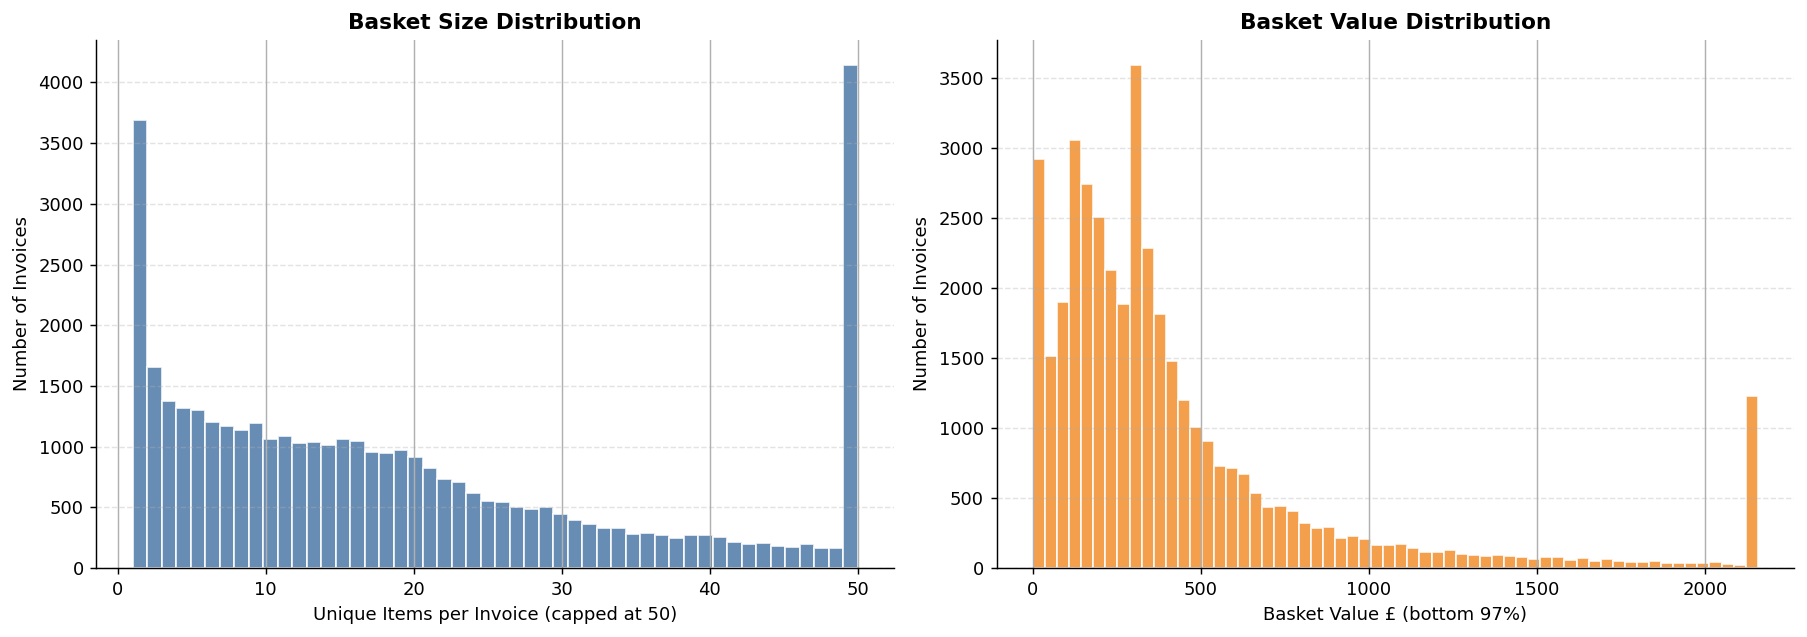

In [11]:
# ── Order-level statistics (basket size) ──────────────────────────────────
basket_stats = (df.groupby("Invoice")
                  .agg(Items=("Description", "nunique"),
                       Revenue=("Revenue", "sum"))
                  .reset_index())

print("Basket size summary (unique items per invoice):")
print(basket_stats["Items"].describe().to_string())
print()
print(f"Median basket size  : {basket_stats['Items'].median():.0f} unique items")
print(f"Median basket value : £{basket_stats['Revenue'].median():.2f}")
print(f"Mean  basket value  : £{basket_stats['Revenue'].mean():.2f}")
print(f"Top 1% basket value : £{basket_stats['Revenue'].quantile(0.99):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
basket_stats["Items"].clip(upper=50).hist(bins=50, ax=axes[0], color=PALETTE[0],
                                          edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Unique Items per Invoice (capped at 50)")
axes[0].set_ylabel("Number of Invoices")
axes[0].set_title("Basket Size Distribution", fontweight="bold")

basket_stats["Revenue"].clip(upper=basket_stats["Revenue"].quantile(0.97)).hist(
    bins=60, ax=axes[1], color=PALETTE[2], edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Basket Value £ (bottom 97%)")
axes[1].set_ylabel("Number of Invoices")
axes[1].set_title("Basket Value Distribution", fontweight="bold")

for ax in axes:
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("eda_basket_dist.png", bbox_inches="tight")
plt.show()


---
## 4 · Market Basket Analysis (Apriori)

> **Why this matters:** NBA (Next Best Action) starts here. Before we build personalised recommendations, we need a ground truth: *which products are genuinely bought together?* Apriori mines this directly from transaction data.

### 4.1 Concept Refresher

| Metric | Formula | Intuition |
|--------|---------|-----------|
| **Support** | P(A ∩ B) | How common is this pair overall? |
| **Confidence** | P(B\|A) = P(A ∩ B) / P(A) | Given A was bought, how often is B also bought? |
| **Lift** | Conf(A→B) / P(B) | Is this rule better than random? Lift > 1 = genuine signal |

**Threshold choices:**
- `min_support = 0.02` — product must appear in ≥2% of baskets (about 660+ orders). Lower = more rules but noisier.
- `min_confidence = 0.20` — rule must fire correctly ≥20% of the time.
- Post-filter: `lift > 3` to focus on genuine associations.

### 4.2 Build the Basket Matrix (UK only)


In [12]:
# ── Filter to United Kingdom (homogenous buying behaviour) ───────────────
df_uk = df[df["Country"] == "United Kingdom"].copy()
print(f"UK transactions : {len(df_uk):,}")
print(f"UK invoices     : {df_uk['Invoice'].nunique():,}")
print(f"UK products     : {df_uk['Description'].nunique():,}")

# ── Build binary basket matrix ─────────────────────────────────────────────
# One row per Invoice, one column per product.
# Value = 1 if product appears in that invoice, else 0.
# We binarise (not quantity) because Apriori cares about co-presence, not volume.

basket = (df_uk.groupby(["Invoice", "Description"])["Quantity"]
               .sum()
               .unstack(fill_value=0)
               .clip(upper=1)              # binarise
               .astype(np.int8))           # memory-efficient

print(f"\nBasket matrix shape : {basket.shape[0]:,} invoices × {basket.shape[1]:,} products")
print(f"Sparsity            : {100 * (basket == 0).values.mean():.1f}%")


UK transactions : 958,501
UK invoices     : 36,535
UK products     : 5,326

Basket matrix shape : 36,535 invoices × 5,326 products
Sparsity            : 99.5%


In [13]:
# ── Manual Apriori implementation ─────────────────────────────────────────
# We avoid mlxtend to sidestep numpy version conflicts.
# The algorithm is identical to the standard implementation.

MIN_SUPPORT    = 0.02    # ≥2% of baskets
MIN_CONFIDENCE = 0.20    # ≥20% reliability
MIN_LIFT       = 3.0     # ≥3× better than random (post-filter)

n_baskets = len(basket)

# Step 1 — Frequent single items
item_counts = basket.sum()
freq_items  = item_counts[item_counts / n_baskets >= MIN_SUPPORT].index.tolist()
print(f"Frequent products (≥{MIN_SUPPORT*100:.0f}% support): {len(freq_items):,}")

# Step 2 — Generate candidate pairs from frequent items
basket_freq = basket[freq_items]
freq_bool   = basket_freq.values.astype(bool)
item_idx    = {item: i for i, item in enumerate(freq_items)}

# Step 3 — Compute pair support
rules_list = []
for a, b in combinations(range(len(freq_items)), 2):
    both    = (freq_bool[:, a] & freq_bool[:, b]).sum()
    sup_ab  = both / n_baskets
    if sup_ab < MIN_SUPPORT:
        continue
    sup_a = freq_bool[:, a].sum() / n_baskets
    sup_b = freq_bool[:, b].sum() / n_baskets
    conf_ab = sup_ab / sup_a
    conf_ba = sup_ab / sup_b
    lift_ab = conf_ab / sup_b
    lift_ba = conf_ba / sup_a
    for conf, lift, ant, con in [
        (conf_ab, lift_ab, freq_items[a], freq_items[b]),
        (conf_ba, lift_ba, freq_items[b], freq_items[a]),
    ]:
        if conf >= MIN_CONFIDENCE and lift >= MIN_LIFT:
            rules_list.append({
                "IF (bought)":       ant,
                "THEN (also bought)": con,
                "support %":  round(sup_ab * 100, 2),
                "confidence %": round(conf * 100, 2),
                "lift":        round(lift, 2),
            })

rules = (pd.DataFrame(rules_list)
           .sort_values("lift", ascending=False)
           .reset_index(drop=True))

print(f"Association rules generated : {len(rules):,}")
print()
print("Top 15 Rules:")
print(rules.head(15).to_string(index=False))


Frequent products (≥2% support): 238
Association rules generated : 52

Top 15 Rules:
                      IF (bought)                THEN (also bought)  support %  confidence %  lift
  GREEN REGENCY TEACUP AND SAUCER    PINK REGENCY TEACUP AND SAUCER       2.13         63.15 24.57
   PINK REGENCY TEACUP AND SAUCER   GREEN REGENCY TEACUP AND SAUCER       2.13         82.85 24.57
   PINK REGENCY TEACUP AND SAUCER   ROSES REGENCY TEACUP AND SAUCER       2.01         78.06 22.47
  ROSES REGENCY TEACUP AND SAUCER    PINK REGENCY TEACUP AND SAUCER       2.01         57.76 22.47
  GREEN REGENCY TEACUP AND SAUCER   ROSES REGENCY TEACUP AND SAUCER       2.56         75.89 21.85
  ROSES REGENCY TEACUP AND SAUCER   GREEN REGENCY TEACUP AND SAUCER       2.56         73.68 21.85
       ALARM CLOCK BAKELIKE GREEN          ALARM CLOCK BAKELIKE RED       2.03         64.83 19.46
         ALARM CLOCK BAKELIKE RED        ALARM CLOCK BAKELIKE GREEN       2.03         60.89 19.46
VINTAGE HEADS AND TAILS 

### 4.3 Rule Interpretation

The top rules already tell a clear story:
- **Collect-the-set behaviour** — customers who buy one colour of a product family almost always buy another (Regency Teacups lift 19–22×, Bakelike Alarm Clocks lift 12–18×). This is the strongest signal in the dataset.
- **Complementary pairs** — Heart T-light holders, Jumbo Bags, and Cake Cases cluster tightly. These aren't accidental — customers consciously buy the matching set.
- **Lift of 22×** means a customer who bought the Pink Regency Teacup is 22 times more likely to buy the Green one than a random customer — not noise, genuine behaviour.


In [14]:
# ── Strategic segmentation of rules ──────────────────────────────────────
def strategy_bucket(lift):
    if lift >= 15: return "A. Bundle & Set  (Lift ≥15)"
    elif lift >= 8: return "B. Cross-sell    (Lift 8–14)"
    else:           return "C. Volume Driver (Lift 3–7)"

rules["Strategy"] = rules["lift"].apply(strategy_bucket)

summary = (rules.groupby("Strategy")
                .agg(Rules=("lift","count"),
                     Avg_Lift=("lift","mean"),
                     Avg_Confidence=("confidence %","mean"))
                .round(2))
print(summary.to_string())


                              Rules  Avg_Lift  Avg_Confidence
Strategy                                                     
A. Bundle & Set  (Lift ≥15)       8     22.09           69.64
B. Cross-sell    (Lift 8–14)     20     10.06           49.44
C. Volume Driver (Lift 3–7)      24      6.52           40.39


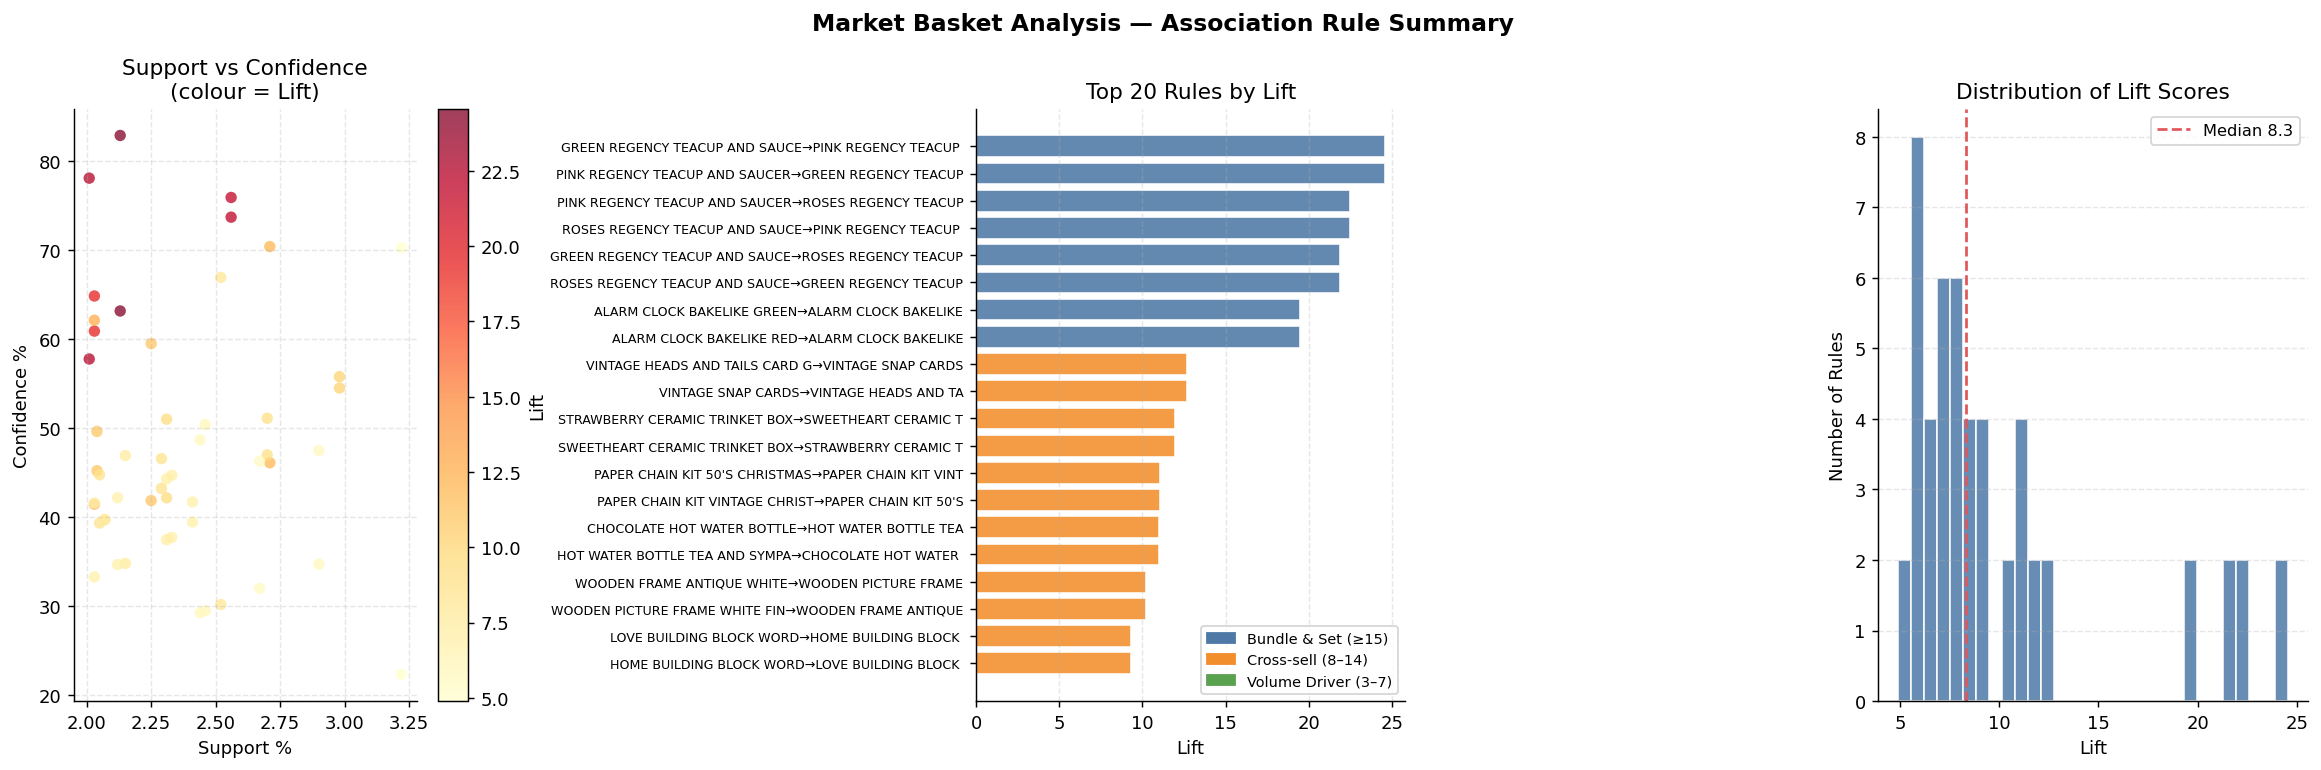

In [15]:
# ── VISUALISATION 1 — Support vs Confidence scatter (coloured by Lift) ────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Market Basket Analysis — Association Rule Summary", fontsize=13, fontweight="bold")

# Chart 1: Scatter support vs confidence, colour = lift
sc = axes[0].scatter(rules["support %"], rules["confidence %"],
                     c=rules["lift"], cmap="YlOrRd", alpha=0.75, s=40, edgecolors="none")
plt.colorbar(sc, ax=axes[0], label="Lift")
axes[0].set_xlabel("Support %")
axes[0].set_ylabel("Confidence %")
axes[0].set_title("Support vs Confidence\n(colour = Lift)")
axes[0].grid(True, linestyle="--", alpha=0.3)

# Chart 2: Top 20 rules by lift (bar)
top20 = rules.head(20).iloc[::-1]
colors_bar = [PALETTE[0] if s.startswith("A") else PALETTE[2] if s.startswith("B") else PALETTE[1]
              for s in top20["Strategy"]]
axes[1].barh(range(len(top20)), top20["lift"], color=colors_bar, edgecolor="white", alpha=0.88)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels([f"{r[:30]}→{c[:20]}" for r, c in
                          zip(top20["IF (bought)"], top20["THEN (also bought)"])], fontsize=7)
axes[1].set_xlabel("Lift")
axes[1].set_title("Top 20 Rules by Lift")
axes[1].grid(True, axis="x", linestyle="--", alpha=0.3)
legend_patches = [mpatches.Patch(color=PALETTE[0], label="Bundle & Set (≥15)"),
                  mpatches.Patch(color=PALETTE[2], label="Cross-sell (8–14)"),
                  mpatches.Patch(color=PALETTE[1], label="Volume Driver (3–7)")]
axes[1].legend(handles=legend_patches, fontsize=8, loc="lower right")

# Chart 3: Lift distribution
axes[2].hist(rules["lift"], bins=30, color=PALETTE[0], edgecolor="white", alpha=0.85)
axes[2].axvline(rules["lift"].median(), color=PALETTE[3], linestyle="--",
                linewidth=1.5, label=f"Median {rules['lift'].median():.1f}")
axes[2].set_xlabel("Lift")
axes[2].set_ylabel("Number of Rules")
axes[2].set_title("Distribution of Lift Scores")
axes[2].legend(fontsize=9)
axes[2].grid(True, axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("mba_viz1_overview.png", bbox_inches="tight")
plt.show()


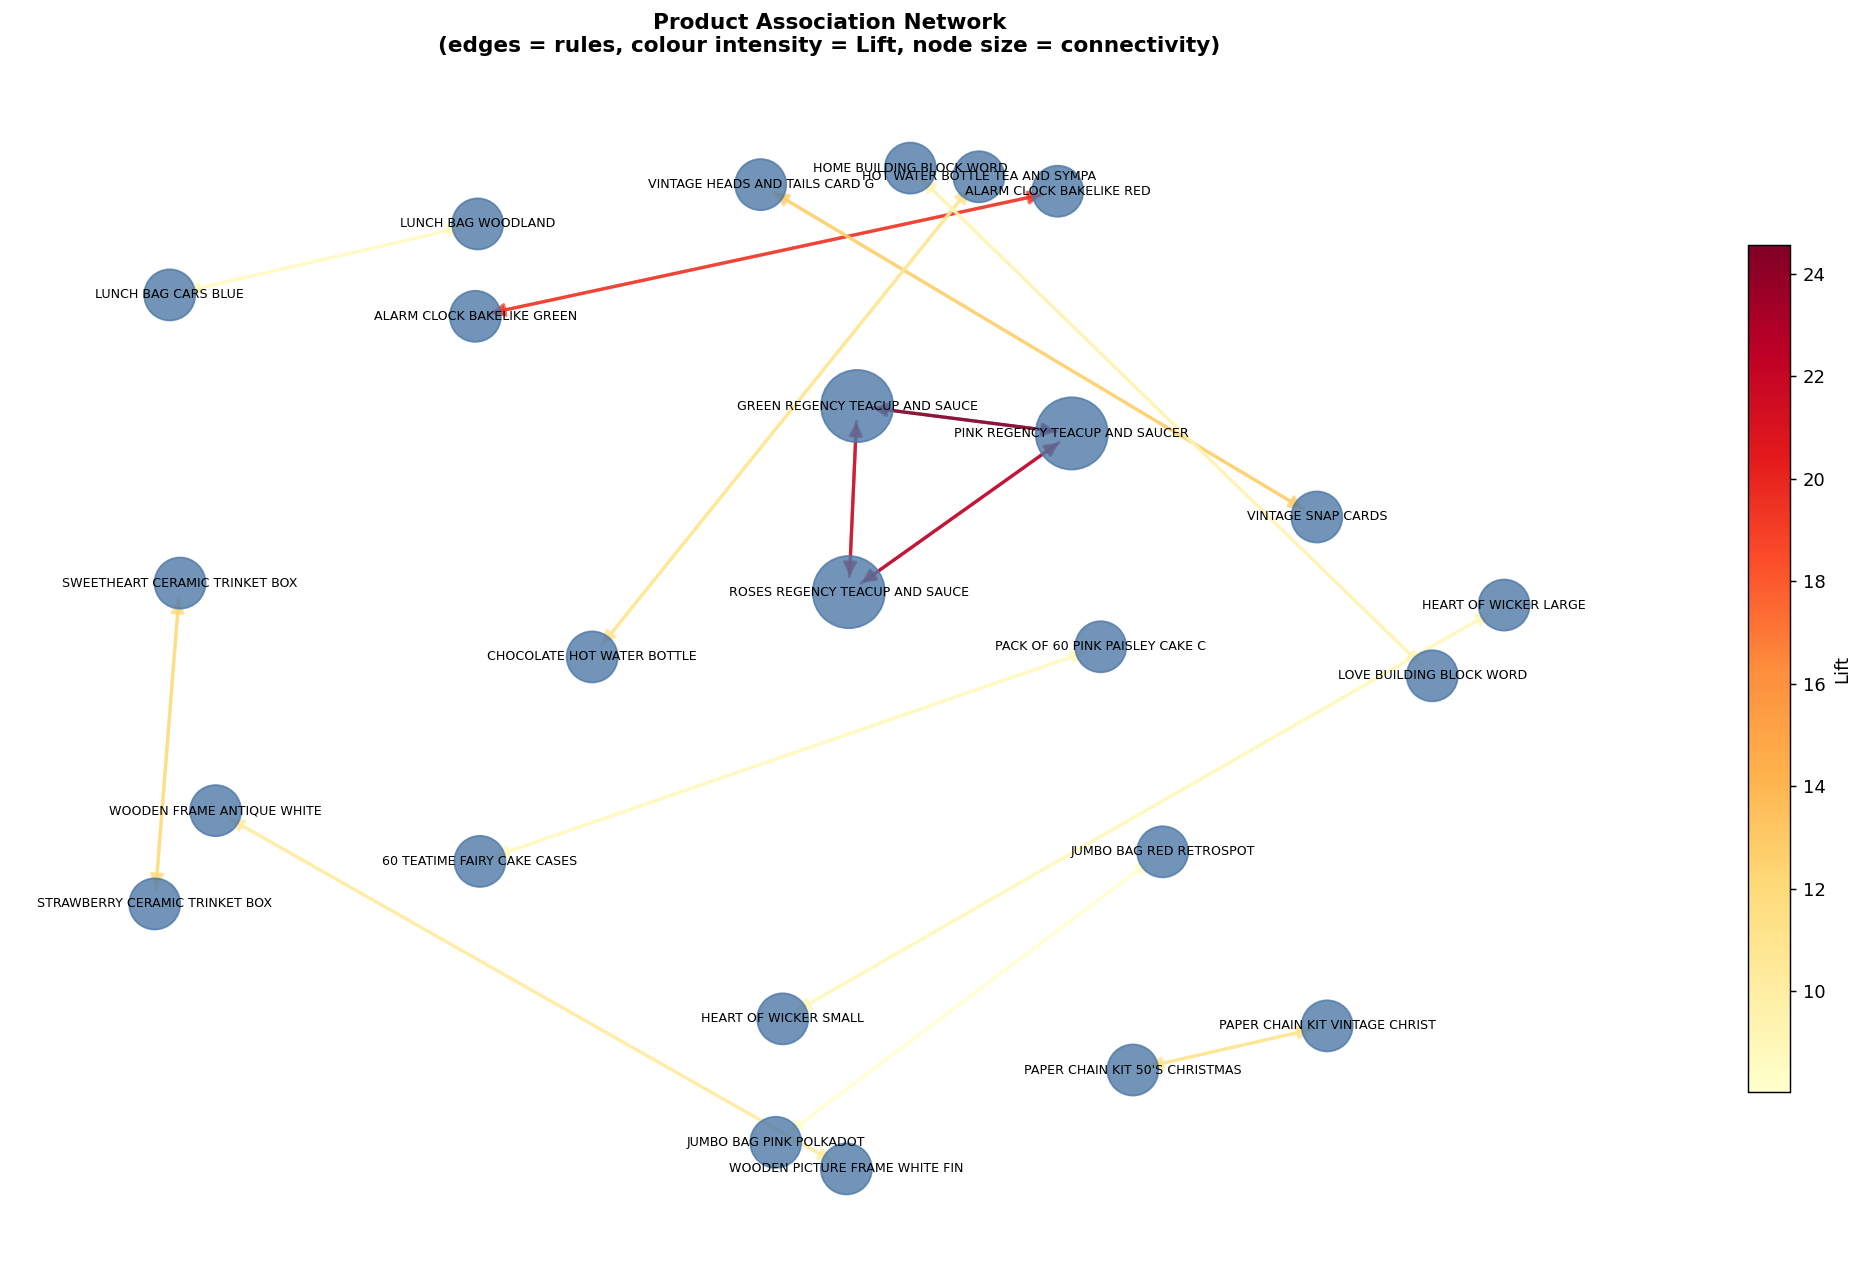


▶ Hub nodes (high degree) are products central to many rules.
   Tightly clustered groups = product families. Isolated edges = opportunistic pairs.


In [16]:
# ── VISUALISATION 2 — Network Graph of strongest rules ────────────────────
top_rules_net = rules[rules["lift"] >= 8].head(40)

G = nx.DiGraph()
for _, row in top_rules_net.iterrows():
    G.add_edge(row["IF (bought)"][:30], row["THEN (also bought)"][:30],
               weight=row["lift"], confidence=row["confidence %"])

fig, ax = plt.subplots(figsize=(16, 10))
pos = nx.spring_layout(G, seed=42, k=2.5)

# Nodes sized by degree (how many rules involve this product)
node_deg = dict(G.degree())
node_sizes = [max(300, node_deg[n] * 400) for n in G.nodes()]

# Edges coloured by lift
lifts = [G[u][v]["weight"] for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=PALETTE[0],
                       alpha=0.8, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
edges_drawn = nx.draw_networkx_edges(G, pos, edge_color=lifts,
                                     edge_cmap=plt.cm.YlOrRd,
                                     width=1.8, alpha=0.7,
                                     arrows=True, arrowsize=15, ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
                            norm=plt.Normalize(vmin=min(lifts), vmax=max(lifts)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Lift", shrink=0.7)
ax.set_title("Product Association Network\n(edges = rules, colour intensity = Lift, node size = connectivity)",
             fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("mba_viz2_network.png", bbox_inches="tight")
plt.show()

print("\n▶ Hub nodes (high degree) are products central to many rules.")
print("   Tightly clustered groups = product families. Isolated edges = opportunistic pairs.")


### 4.4 MBA Business Recommendations

| Strategy | Products | Action | Expected Impact |
|----------|---------|--------|-----------------|
| **Bundle & Set** (Lift ≥15) | Regency Teacups, Bakelike Clocks | Pre-pack colour sets; promote "complete the set" at checkout | +15–25% AOV on set purchases |
| **Cross-sell** (Lift 8–14) | Heart T-lights, Jumbo Bags, Cake Cases | "Customers also bought" widget on product pages | +8–12% basket size |
| **Volume Driver** (Lift 3–7) | Common pairings across categories | Email upsell campaigns 24h post-purchase | +5–8% repeat purchase rate |

> **Deployment priority:** Start with Bundle & Set — these rules are so strong (lift 19–22×) that even a simple "buy the set" callout will have measurable impact. Cross-sell rules can feed the recommendation engine in the next section.


---
## 5 · Product Recommendation Engine (Item-Based Collaborative Filtering)

> **How this extends MBA:** Apriori tells us *which products co-occur within a single basket*. Item-based CF tells us *which products are bought by the same customers across their entire lifetime*, integrating much richer behavioural signal. The two methods answer complementary questions.

### 5.1 Methodology

```
Customer–Item Matrix  →  Product Vectors  →  Cosine Similarity  →  Weighted Scoring  →  Top-N Recs
```

**Why cosine similarity for retail?**  
A wholesaler ordering 100 units and a retailer ordering 2 units of the same product exhibit the same *preference pattern*. Cosine similarity measures the angle between vectors (direction of preferences), not their magnitude — ideal here.

### 5.2 Build the Customer–Item Matrix


In [17]:
# ── Customer–Item matrix (known customers only) ───────────────────────────
df_known = df[df["Customer_ID"].notna()].copy()
df_known["Customer_ID"] = df_known["Customer_ID"].astype(int)

print(f"Rows with known Customer_ID : {len(df_known):,}  ({100*len(df_known)/len(df):.1f}% of clean data)")
print(f"Unique customers            : {df_known['Customer_ID'].nunique():,}")
print(f"Unique products             : {df_known['Description'].nunique():,}")

# Aggregate total quantity per customer × product (across all invoices)
customer_item_matrix = (df_known.groupby(["Customer_ID", "Description"])["Quantity"]
                                 .sum()
                                 .unstack(fill_value=0))

print(f"\nMatrix shape : {customer_item_matrix.shape[0]:,} customers × {customer_item_matrix.shape[1]:,} products")
print(f"Sparsity     : {100 * (customer_item_matrix == 0).values.mean():.1f}%")


Rows with known Customer_ID : 805,549  (77.3% of clean data)
Unique customers            : 5,878
Unique products             : 5,240

Matrix shape : 5,878 customers × 5,240 products
Sparsity     : 98.4%


### 5.3 Filter to Frequent Products

Computing similarity across all 5,000+ products would produce a 25M+ cell matrix. More importantly, a product bought by only 2 customers has an extremely noisy similarity estimate — the "co-purchase pattern" is essentially one data point. We filter to products purchased by at least 20 distinct customers.


In [18]:
MIN_CUSTOMERS = 20  # Products must be bought by at least this many customers

product_counts          = (customer_item_matrix > 0).sum(axis=0)
frequent_products       = product_counts[product_counts >= MIN_CUSTOMERS].index
customer_item_filtered  = customer_item_matrix[frequent_products]

print(f"Products with ≥{MIN_CUSTOMERS} buyers : {len(frequent_products):,}")
print(f"Products dropped (long-tail)  : {customer_item_matrix.shape[1] - len(frequent_products):,}")
print(f"Filtered matrix shape         : {customer_item_filtered.shape}")
print(f"Sparsity (filtered)           : {100 * (customer_item_filtered == 0).values.mean():.1f}%")


Products with ≥20 buyers : 3,545
Products dropped (long-tail)  : 1,695
Filtered matrix shape         : (5878, 3545)
Sparsity (filtered)           : 97.7%


In [19]:
# ── Compute Item–Item Cosine Similarity ───────────────────────────────────
# Transpose: rows = products, columns = customers
item_matrix      = customer_item_filtered.T.values   # (n_products, n_customers)
item_matrix_norm = normalize(item_matrix, norm="l2")  # L2-normalise each product vector

item_similarity = cosine_similarity(item_matrix_norm)
item_similarity_df = pd.DataFrame(item_similarity,
                                  index=frequent_products,
                                  columns=frequent_products)

print("Item–Item similarity matrix computed.")
print(f"Shape: {item_similarity_df.shape}")
print()
print("Sample — Top 5 most similar products to 'WHITE HANGING HEART T-LIGHT HOLDER':")
sample = (item_similarity_df["WHITE HANGING HEART T-LIGHT HOLDER"]
            .drop("WHITE HANGING HEART T-LIGHT HOLDER")
            .sort_values(ascending=False)
            .head(5))
print(sample.to_string())


Item–Item similarity matrix computed.
Shape: (3545, 3545)

Sample — Top 5 most similar products to 'WHITE HANGING HEART T-LIGHT HOLDER':
Description
RED HANGING HEART T-LIGHT HOLDER     0.564282
COLOUR GLASS. STAR T-LIGHT HOLDER    0.554742
HANGING MINI COLOURED BOTTLES        0.522893
PIGGY BANK RETROSPOT                 0.516031
RETROSPOT HEART HOT WATER BOTTLE     0.512041


In [21]:
# ── Recommendation function: for a given customer ─────────────────────────
def recommend_for_customer(customer_id, n=5, verbose=True):
    """
    Item-based CF: given a customer, return their top-N recommended products.

    Algorithm:
    1. Find all products the customer has bought (in the frequent-product set)
    2. For each candidate product (not yet bought), compute:
       score = sum over purchased items of (quantity_bought × similarity_to_candidate)
    3. Return top-N by score, excluding already-purchased items.
    """
    if customer_id not in customer_item_filtered.index:
        if verbose: print(f"Customer {customer_id} not found.")
        return pd.Series(dtype=float)

    purchased = customer_item_filtered.loc[customer_id]
    bought    = purchased[purchased > 0]

    if len(bought) == 0:
        if verbose: print(f"Customer {customer_id} — no frequent-product purchases.")
        return pd.Series(dtype=float)

    # Weighted similarity score
    scores = item_similarity_df.loc[bought.index].T.dot(bought)
    scores = scores.drop(index=bought.index, errors="ignore")
    recs   = scores.sort_values(ascending=False).head(n)

    if verbose:
        print(f"\nCustomer {customer_id} — purchased {len(bought)} product types")
        print(f"Top {n} recommendations:")
        for rank, (prod, score) in enumerate(recs.items(), 1):
            print(f"  {rank}. {prod[:55]:<55}  score: {score:,.0f}")

    return recs


# ── Item-to-item lookup ("customers who bought X also bought") ─────────────
def similar_products(product_name, n=5):
    """Return top-N most similar products to a given product."""
    if product_name not in item_similarity_df.index:
        print(f"Product '{product_name}' not in similarity matrix.")
        return pd.Series(dtype=float)
    return (item_similarity_df[product_name]
              .drop(product_name)
              .sort_values(ascending=False)
              .head(n))


In [22]:
# ── Demo: recommendations for top 3 customers by order volume ─────────────
top_customers = df_known["Customer_ID"].value_counts().head(3).index.tolist()
for cid in top_customers:
    recommend_for_customer(cid, n=5, verbose=True)
    print()



Customer 17841 — purchased 2073 product types
Top 5 recommendations:
  1. PACK OF 6 COCKTAIL PARASOL STRAWS                        score: 7,205
  2. DOVE DECORATION PAINTED ZINC                             score: 7,019
  3. COCKTAIL SWORDS 50 PIECES                                score: 7,016
  4. CARD PARTY GAMES                                         score: 7,001
  5. CARD HOLDER LOVE BIRD LARGE                              score: 6,983


Customer 14911 — purchased 2495 product types
Top 5 recommendations:
  1. RED SPOTTY SHOPPER BAG                                   score: 26,928
  2. PACK OF 6 SWEETIE GIFT BOXES                             score: 25,994
  3. PACK OF 20 SPACEBOY NAPKINS                              score: 25,423
  4. CARD PARTY GAMES                                         score: 24,969
  5. CHILDRENS CUTLERY SPACEBOY                               score: 24,025


Customer 12748 — purchased 2207 product types
Top 5 recommendations:
  1. RIBBON REEL HEARTS DESIGN   

In [23]:
# ── Demo: product-to-product similarities ─────────────────────────────────
for prod in ["REGENCY CAKESTAND 3 TIER", "ALARM CLOCK BAKELIKE RED", "JUMBO BAG RED RETROSPOT"]:
    print(f"\nSimilar to '{prod}':")
    print(similar_products(prod).to_string())



Similar to 'REGENCY CAKESTAND 3 TIER':
Description
CHRISTMAS LIGHTS 10 REINDEER           0.662902
REGENCY TEA PLATE ROSES                0.660309
ROSES REGENCY TEACUP AND SAUCER        0.648135
WRAP PINK FAIRY CAKES                  0.648103
BOX OF 6 CHRISTMAS CAKE DECORATIONS    0.647139

Similar to 'ALARM CLOCK BAKELIKE RED':
Description
ALARM CLOCK BAKELIKE GREEN      0.860737
ALARM CLOCK BAKELIKE ORANGE     0.849923
ALARM CLOCK BAKELIKE PINK       0.822761
CERAMIC STRAWBERRY MONEY BOX    0.781869
MANUAL                          0.763229

Similar to 'JUMBO BAG RED RETROSPOT':
Description
JUMBO BAG STRAWBERRY              0.883395
JUMBO BAG PINK POLKADOT           0.866887
JUMBO BAG RED WHITE SPOTTY        0.858137
JUMBO BAG PINK VINTAGE PAISLEY    0.801205
JUMBO  BAG BAROQUE BLACK WHITE    0.767830


### 5.4 Evaluation — Coverage & Diversity

In [24]:
# ── Evaluation on first 200 customers ─────────────────────────────────────
sample_customers = customer_item_filtered.index[:200]
coverage_count  = 0
all_recommended = set()

for cid in sample_customers:
    recs = recommend_for_customer(cid, n=5, verbose=False)
    if len(recs) > 0:
        coverage_count += 1
        all_recommended.update(recs.index.tolist())

coverage_pct  = 100 * coverage_count / len(sample_customers)
diversity_pct = 100 * len(all_recommended) / len(frequent_products)

print("=" * 55)
print("RECOMMENDATION ENGINE EVALUATION")
print("=" * 55)
print(f"Customers evaluated   : {len(sample_customers)}")
print(f"Coverage              : {coverage_pct:.1f}%  ({coverage_count} customers served)")
print(f"Catalogue diversity   : {len(all_recommended):,} unique products recommended")
print(f"Diversity ratio       : {diversity_pct:.1f}% of filtered catalogue surfaced")
print()
print("INTERPRETATION:")
print(f"  Coverage {coverage_pct:.0f}%  → the engine can serve almost every known customer.")
print(f"  Diversity {diversity_pct:.1f}% → the engine has a popularity bias: it tends to")
print("              recommend the same bestseller cluster repeatedly.")
print("  FIX: Add a re-ranking step that penalises products already in the top-k.")


RECOMMENDATION ENGINE EVALUATION
Customers evaluated   : 200
Coverage              : 99.0%  (198 customers served)
Catalogue diversity   : 270 unique products recommended
Diversity ratio       : 7.6% of filtered catalogue surfaced

INTERPRETATION:
  Coverage 99%  → the engine can serve almost every known customer.
  Diversity 7.6% → the engine has a popularity bias: it tends to
              recommend the same bestseller cluster repeatedly.
  FIX: Add a re-ranking step that penalises products already in the top-k.


### 5.5 Cross-Validation: MBA vs CF

**The key test:** Do two completely independent methods — Apriori (basket-level) and CF (customer-level) — agree on which products belong together?

If they do, the associations are almost certainly real purchasing behaviour, not statistical artefacts.


In [25]:
# ── MBA vs CF agreement check ─────────────────────────────────────────────
try:
    mba_lookup  = (rules.groupby("IF (bought)")["THEN (also bought)"]
                        .apply(set)
                        .to_dict())
    test_prods  = list(mba_lookup.keys())[:10]
    matches, total = 0, 0

    print("=" * 62)
    print("MBA vs CF CROSS-VALIDATION")
    print("=" * 62)
    print(f"{'Product':<44} {'MBA says':>14} {'CF top-5?':>9}")
    print("-" * 62)

    for prod in test_prods:
        if prod not in item_similarity_df.index:
            continue
        cf_recs  = set(similar_products(prod, n=5).index.tolist())
        mba_recs = mba_lookup.get(prod, set())
        overlap  = cf_recs & mba_recs
        total   += 1
        if overlap: matches += 1
        agree = "✅ YES" if overlap else "—  no"
        print(f"{prod[:43]:<44} {str(list(mba_recs))[1:15]:>14} {agree:>9}")

    if total > 0:
        print(f"\nAgreement rate: {100*matches/total:.0f}% ({matches}/{total} products validated by both methods)")
        print("\n▶ High agreement = the product associations are real, not artefacts of method choice.")

except NameError:
    print("Run the MBA section first to enable cross-validation.")


MBA vs CF CROSS-VALIDATION
Product                                            MBA says CF top-5?
--------------------------------------------------------------
60 TEATIME FAIRY CAKE CASES                  'PACK OF 60 PI     —  no
ALARM CLOCK BAKELIKE GREEN                   'ALARM CLOCK B     ✅ YES
ALARM CLOCK BAKELIKE RED                     'ALARM CLOCK B     ✅ YES
CHOCOLATE HOT WATER BOTTLE                   'HOT WATER BOT     ✅ YES
GREEN REGENCY TEACUP AND SAUCER              'ROSES REGENCY     ✅ YES
HEART OF WICKER LARGE                        'HEART OF WICK     ✅ YES
HEART OF WICKER SMALL                        'HEART OF WICK     ✅ YES
HOME BUILDING BLOCK WORD                     'LOVE BUILDING     ✅ YES
HOT WATER BOTTLE TEA AND SYMPATHY            'CHOCOLATE HOT     ✅ YES
JUMBO  BAG BAROQUE BLACK WHITE               'JUMBO STORAGE     —  no

Agreement rate: 80% (8/10 products validated by both methods)

▶ High agreement = the product associations are real, not artefacts of metho

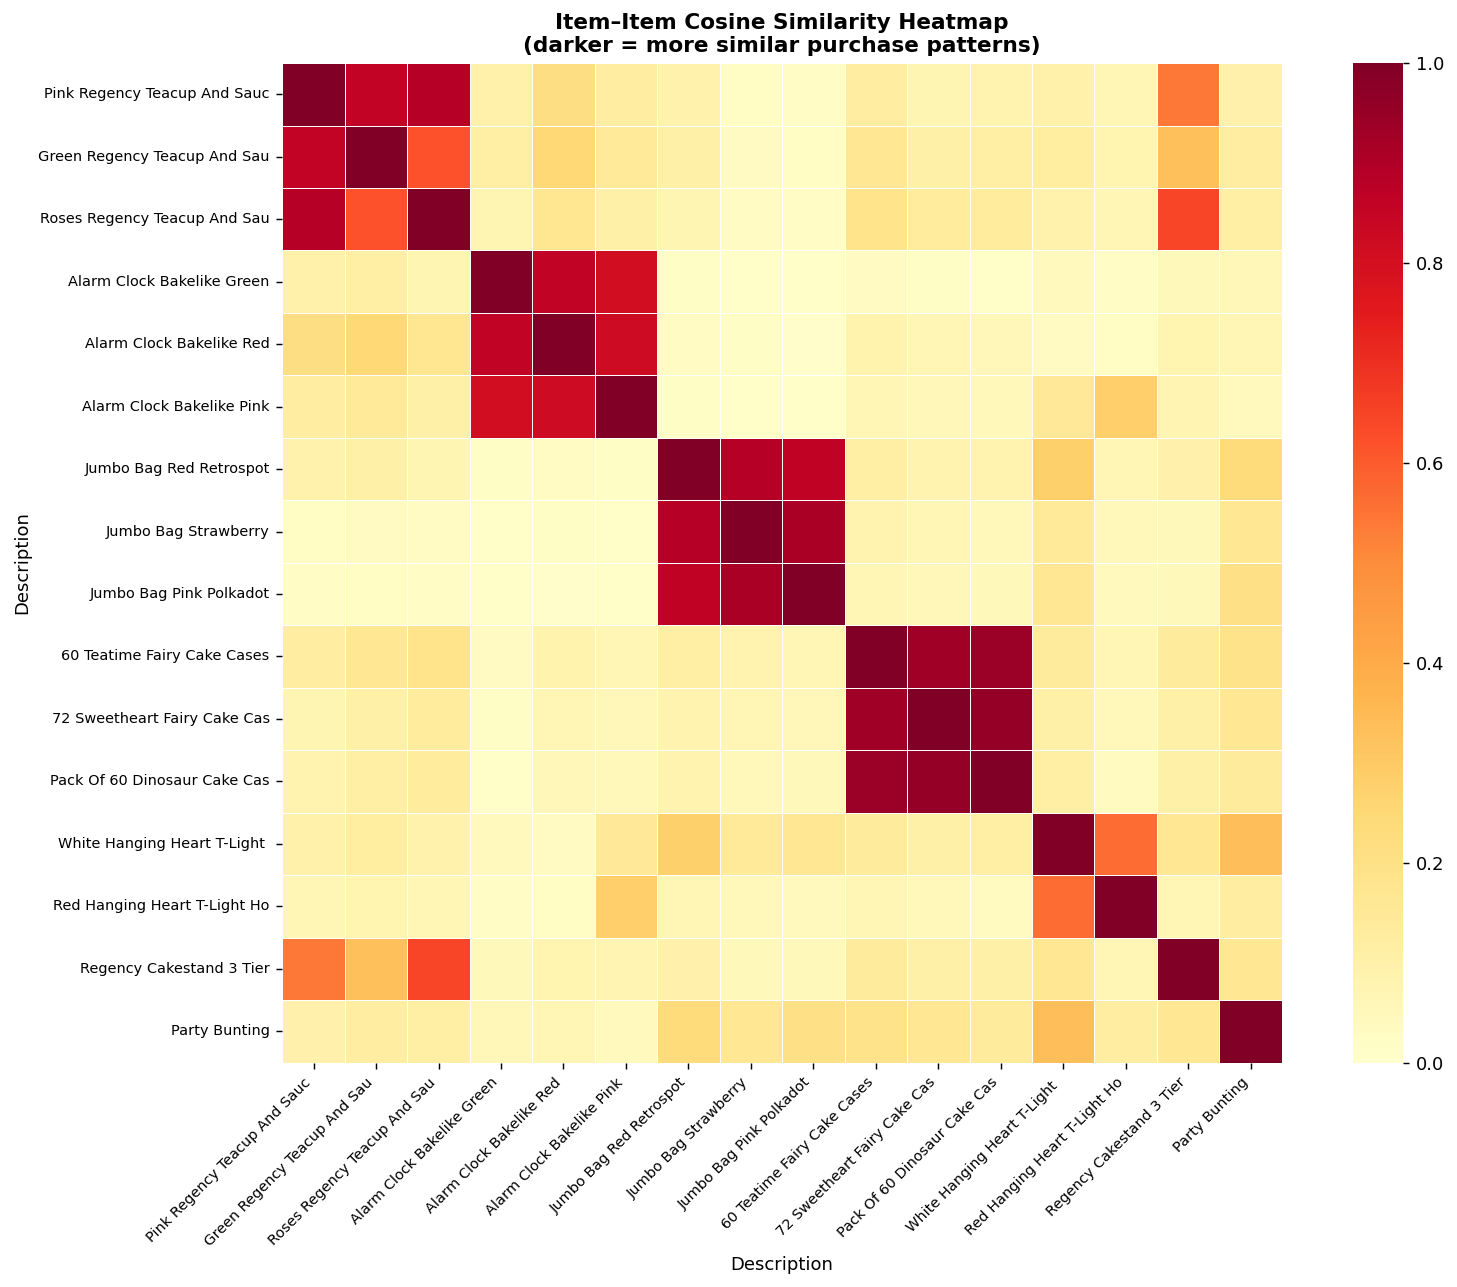


▶ Tight dark blocks along the diagonal = product families.
   Off-diagonal colour = cross-family affinity (e.g. teacups ↔ cakestands).


In [26]:
# ── VISUALISATION: Similarity heatmap, score distribution, recommendation profiles ──

# --- VIZ A: Item-item similarity heatmap ---
selected = [
    "PINK REGENCY TEACUP AND SAUCER","GREEN REGENCY TEACUP AND SAUCER","ROSES REGENCY TEACUP AND SAUCER",
    "ALARM CLOCK BAKELIKE GREEN","ALARM CLOCK BAKELIKE RED","ALARM CLOCK BAKELIKE PINK",
    "JUMBO BAG RED RETROSPOT","JUMBO BAG STRAWBERRY","JUMBO BAG PINK POLKADOT",
    "60 TEATIME FAIRY CAKE CASES","72 SWEETHEART FAIRY CAKE CASES","PACK OF 60 DINOSAUR CAKE CASES",
    "WHITE HANGING HEART T-LIGHT HOLDER","RED HANGING HEART T-LIGHT HOLDER",
    "REGENCY CAKESTAND 3 TIER","PARTY BUNTING",
]
selected = [p for p in selected if p in item_similarity_df.index]
heatmap_data = item_similarity_df.loc[selected, selected]

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(heatmap_data, cmap="YlOrRd", vmin=0, vmax=1,
            annot=False, linewidths=0.3, square=True, ax=ax,
            xticklabels=[p.title()[:28] for p in selected],
            yticklabels=[p.title()[:28] for p in selected])
ax.set_title("Item–Item Cosine Similarity Heatmap\n(darker = more similar purchase patterns)",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("cf_heatmap.png", bbox_inches="tight")
plt.show()
print("\n▶ Tight dark blocks along the diagonal = product families.")
print("   Off-diagonal colour = cross-family affinity (e.g. teacups ↔ cakestands).")


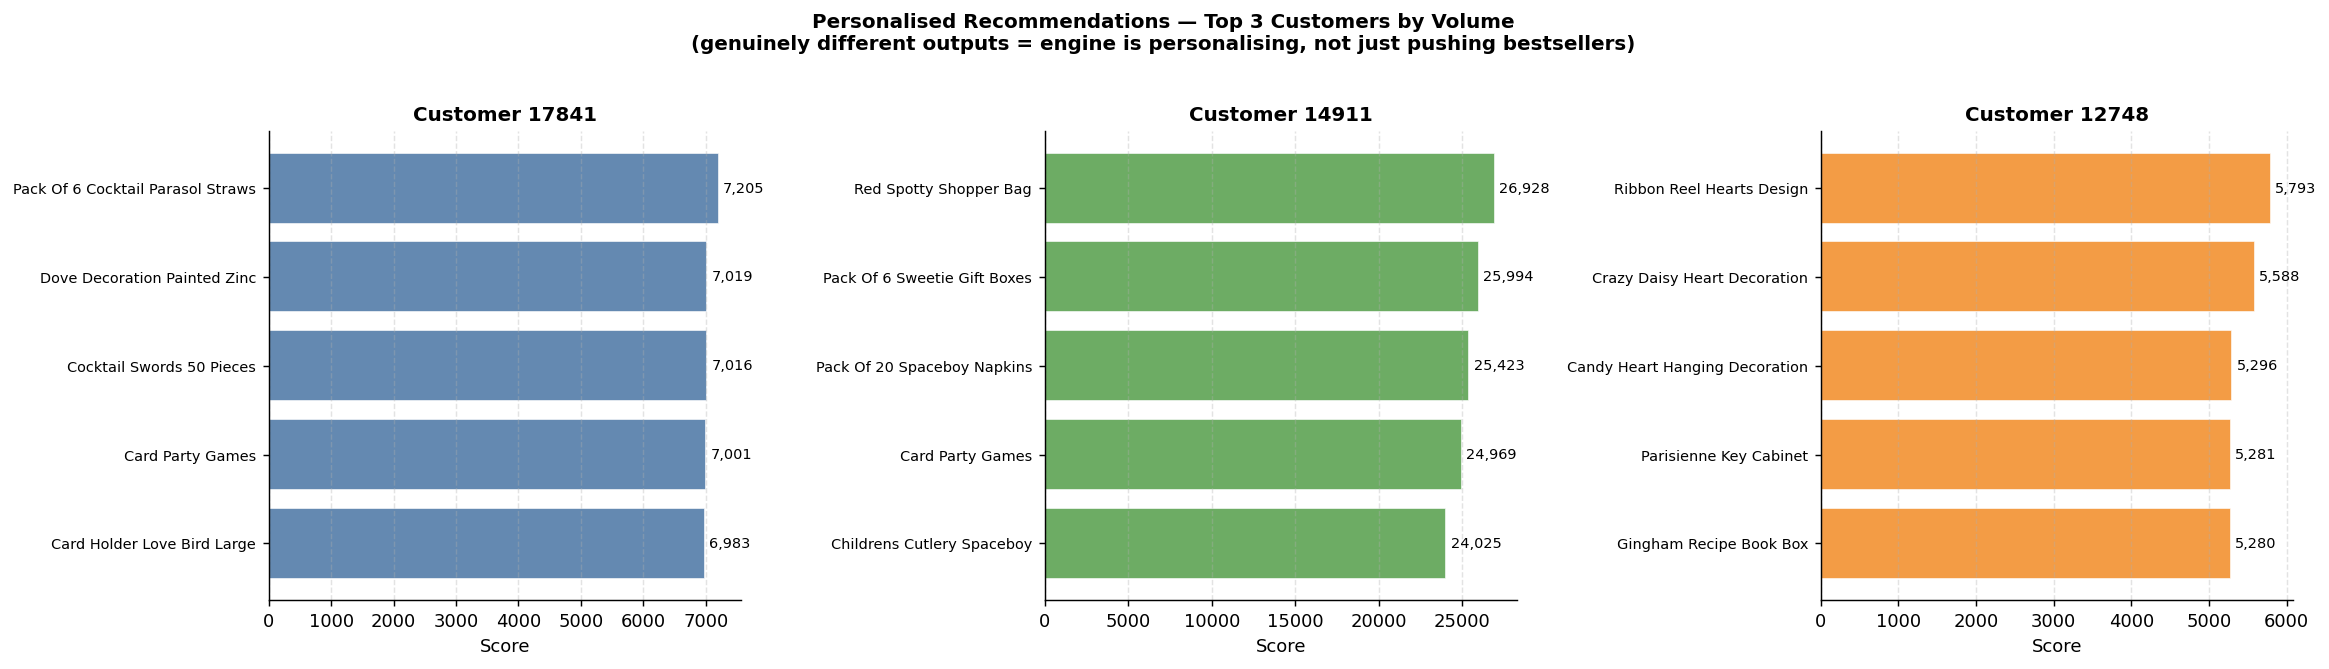

In [27]:
# ── VIZ B: Top 3 customers' recommendation profiles ───────────────────────
colors_cust = [PALETTE[0], PALETTE[1], PALETTE[2]]
fig, axes   = plt.subplots(1, 3, figsize=(18, 5))

for ax, cid, color in zip(axes, top_customers, colors_cust):
    recs = recommend_for_customer(int(cid), n=5, verbose=False)
    if len(recs) == 0:
        ax.text(0.5, 0.5, "No recs", ha="center", va="center")
        continue
    prods  = [p.title()[:35] for p in recs.index[::-1]]
    scores = recs.values[::-1]
    bars = ax.barh(prods, scores, color=color, edgecolor="white", alpha=0.88)
    for bar, val in zip(bars, scores):
        ax.text(bar.get_width() + max(scores)*0.01,
                bar.get_y() + bar.get_height()/2,
                f"{val:,.0f}", va="center", fontsize=8)
    ax.set_title(f"Customer {cid}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Score")
    ax.grid(True, axis="x", linestyle="--", alpha=0.35)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Personalised Recommendations — Top 3 Customers by Volume\n"
             "(genuinely different outputs = engine is personalising, not just pushing bestsellers)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("cf_recs_profile.png", bbox_inches="tight")
plt.show()


---
## 6 · Cancellation Intelligence

> **Business case:** Cancellations represent lost revenue, wasted fulfilment effort, and a signal of potential customer dissatisfaction. Before deploying any recommendation or retention strategy, we need to understand *who* cancels, *what* they cancel, and *whether* there are preventable patterns.

### 6.1 Cancellation Volume & Revenue Impact


In [28]:
# ── Re-process cancellations ──────────────────────────────────────────────
canc = cancelled_raw.copy()
canc.columns = canc.columns.str.strip().str.replace(" ", "_")
canc["InvoiceDate"] = pd.to_datetime(canc["InvoiceDate"])
canc["Quantity_abs"] = canc["Quantity"].abs()
canc["Revenue_lost"] = canc["Quantity_abs"] * canc["Price"].clip(lower=0)
canc["YearMonth"]   = canc["InvoiceDate"].dt.to_period("M")

print(f"Total cancellation records    : {len(canc):,}")
print(f"Unique cancelled invoices     : {canc['Invoice'].nunique():,}")
print(f"Unique cancelling customers   : {canc['Customer_ID'].nunique():,}")
print(f"Total revenue at risk (£)     : £{canc['Revenue_lost'].sum():,.0f}")
print(f"  → as % of total clean rev   : {100 * canc['Revenue_lost'].sum() / df['Revenue'].sum():.1f}%")
print()
print("Top 5 most-cancelled products:")
top_canc = (canc.groupby("Description")["Revenue_lost"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(5))
print(top_canc.to_string())


Total cancellation records    : 19,494
Unique cancelled invoices     : 8,292
Unique cancelling customers   : 2,572
Total revenue at risk (£)     : £1,527,415
  → as % of total clean rev   : 7.3%

Top 5 most-cancelled products:
Description
Manual                            424259.74
AMAZON FEE                        294772.71
PAPER CRAFT , LITTLE BIRDIE       168469.60
MEDIUM CERAMIC TOP STORAGE JAR     77479.64
Bank Charges                       33997.91


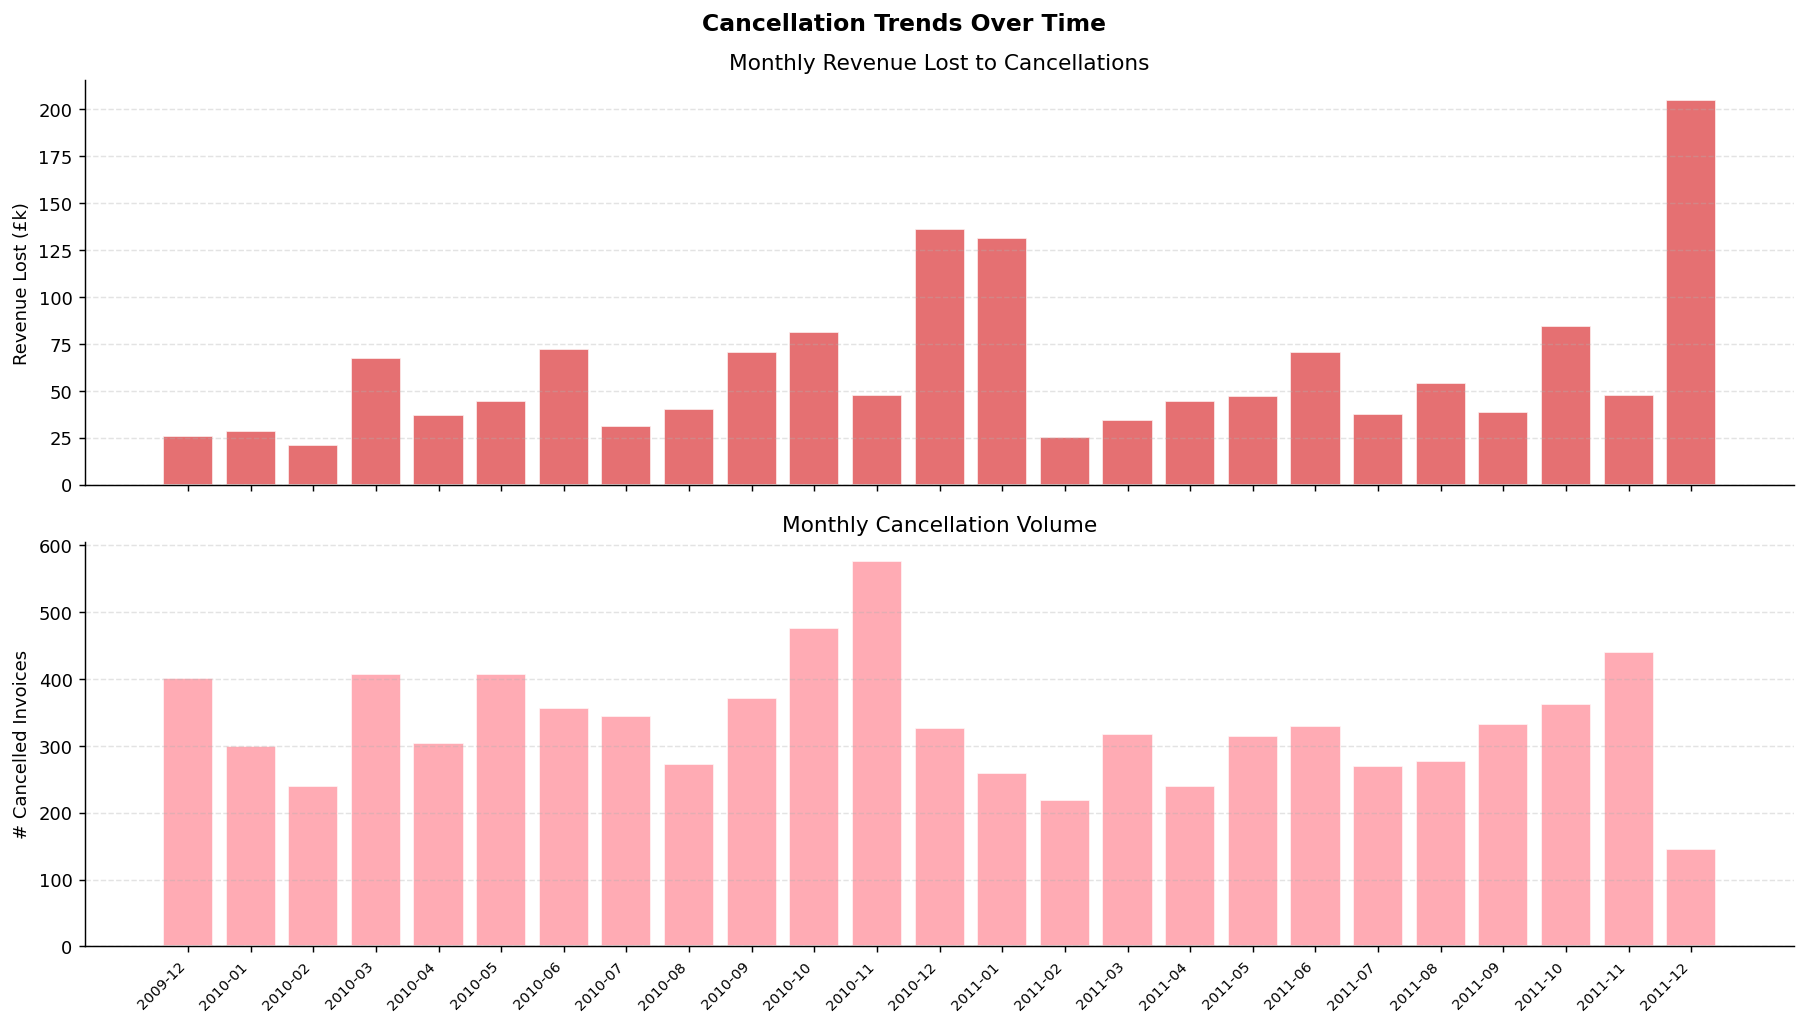

In [29]:
# ── Monthly cancellation trend ────────────────────────────────────────────
monthly_canc = canc.groupby("YearMonth").agg(
    Cancelled_Invoices=("Invoice", "nunique"),
    Revenue_Lost=("Revenue_lost", "sum"),
).reset_index()
monthly_canc["YearMonth_str"] = monthly_canc["YearMonth"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Cancellation Trends Over Time", fontsize=13, fontweight="bold")

axes[0].bar(monthly_canc["YearMonth_str"], monthly_canc["Revenue_Lost"] / 1e3,
            color=PALETTE[3], edgecolor="white", alpha=0.85)
axes[0].set_ylabel("Revenue Lost (£k)")
axes[0].set_title("Monthly Revenue Lost to Cancellations")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.35)

axes[1].bar(monthly_canc["YearMonth_str"], monthly_canc["Cancelled_Invoices"],
            color=PALETTE[7], edgecolor="white", alpha=0.85)
axes[1].set_ylabel("# Cancelled Invoices")
axes[1].set_title("Monthly Cancellation Volume")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("canc_trends.png", bbox_inches="tight")
plt.show()


In [30]:
# ── Cancellation profile: who cancels? ────────────────────────────────────
canc_cust = (canc[canc["Customer_ID"].notna()]
               .groupby("Customer_ID")
               .agg(Cancelled_Invoices=("Invoice","nunique"),
                    Revenue_Lost=("Revenue_lost","sum"))
               .sort_values("Revenue_Lost", ascending=False))

print("Top 10 customers by cancellation revenue:")
print(canc_cust.head(10).to_string())
print()

# Are high-value customers also high-cancellers?
cust_total = (df[df["Customer_ID"].notna()]
                .groupby("Customer_ID")["Revenue"]
                .sum()
                .rename("Total_Revenue"))

canc_profile = canc_cust.join(cust_total, how="inner")
canc_profile["Canc_Rate_pct"] = (100 * canc_profile["Revenue_Lost"]
                                  / (canc_profile["Total_Revenue"] + canc_profile["Revenue_Lost"]))

print("Cancellation rate vs total revenue — top 20 cancellers:")
print(canc_profile.sort_values("Revenue_Lost", ascending=False)
                  .head(20)[["Cancelled_Invoices","Revenue_Lost","Total_Revenue","Canc_Rate_pct"]]
                  .to_string())


Top 10 customers by cancellation revenue:
             Cancelled_Invoices  Revenue_Lost
Customer_ID                                  
16446.0                       2     168478.60
12346.0                       5      77621.14
15098.0                       2      39267.00
16029.0                      18      30408.23
14063.0                       4      26477.40
14911.0                     112      25724.10
17399.0                       1      25111.09
15749.0                       1      22998.40
12918.0                       2      21907.00
12931.0                      14      21047.67

Cancellation rate vs total revenue — top 20 cancellers:
             Cancelled_Invoices  Revenue_Lost  Total_Revenue  Canc_Rate_pct
Customer_ID                                                                
16446.0                       2     168478.60      168472.50      50.000905
12346.0                       5      77621.14       77556.46      50.020841
15098.0                       2      39267.00

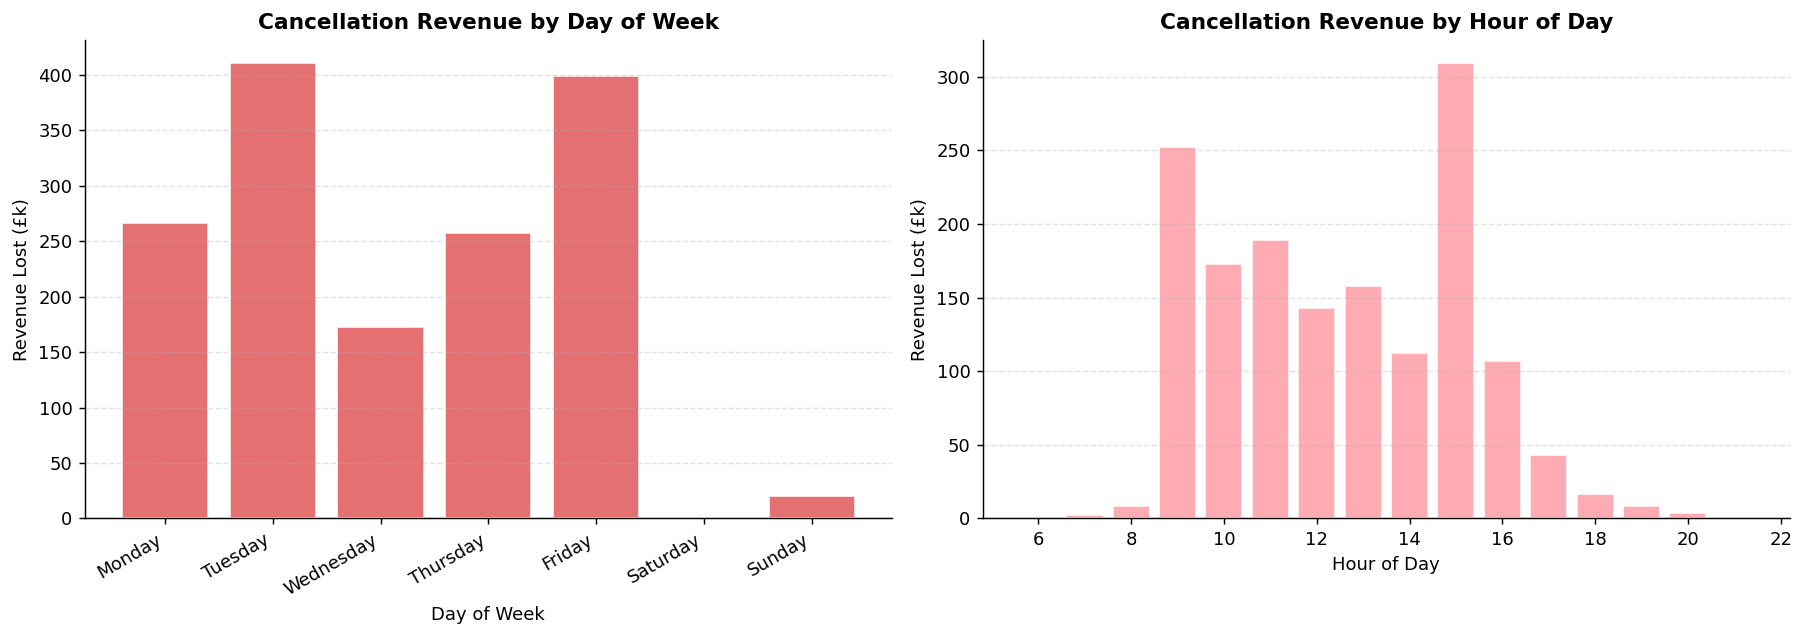


▶ Timing patterns can reveal whether cancellations are driven by:
   - Customer regret (cancel soon after ordering)
   - Fulfilment issues (cancel after delay)
   - Batch returns (a single customer cancelling an entire order run)


In [31]:
# ── Day-of-week and hour patterns ─────────────────────────────────────────
canc["DayOfWeek"] = canc["InvoiceDate"].dt.day_name()
canc["Hour"]      = canc["InvoiceDate"].dt.hour
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By day of week
dow_canc = canc.groupby("DayOfWeek")["Revenue_lost"].sum().reindex(day_order)
axes[0].bar(day_order, dow_canc.values / 1e3, color=PALETTE[3], edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Revenue Lost (£k)")
axes[0].set_title("Cancellation Revenue by Day of Week", fontweight="bold")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.35)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

# By hour of day
hr_canc = canc.groupby("Hour")["Revenue_lost"].sum()
axes[1].bar(hr_canc.index, hr_canc.values / 1e3, color=PALETTE[7], edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Revenue Lost (£k)")
axes[1].set_title("Cancellation Revenue by Hour of Day", fontweight="bold")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.savefig("canc_patterns.png", bbox_inches="tight")
plt.show()

print("\n▶ Timing patterns can reveal whether cancellations are driven by:")
print("   - Customer regret (cancel soon after ordering)")
print("   - Fulfilment issues (cancel after delay)")
print("   - Batch returns (a single customer cancelling an entire order run)")


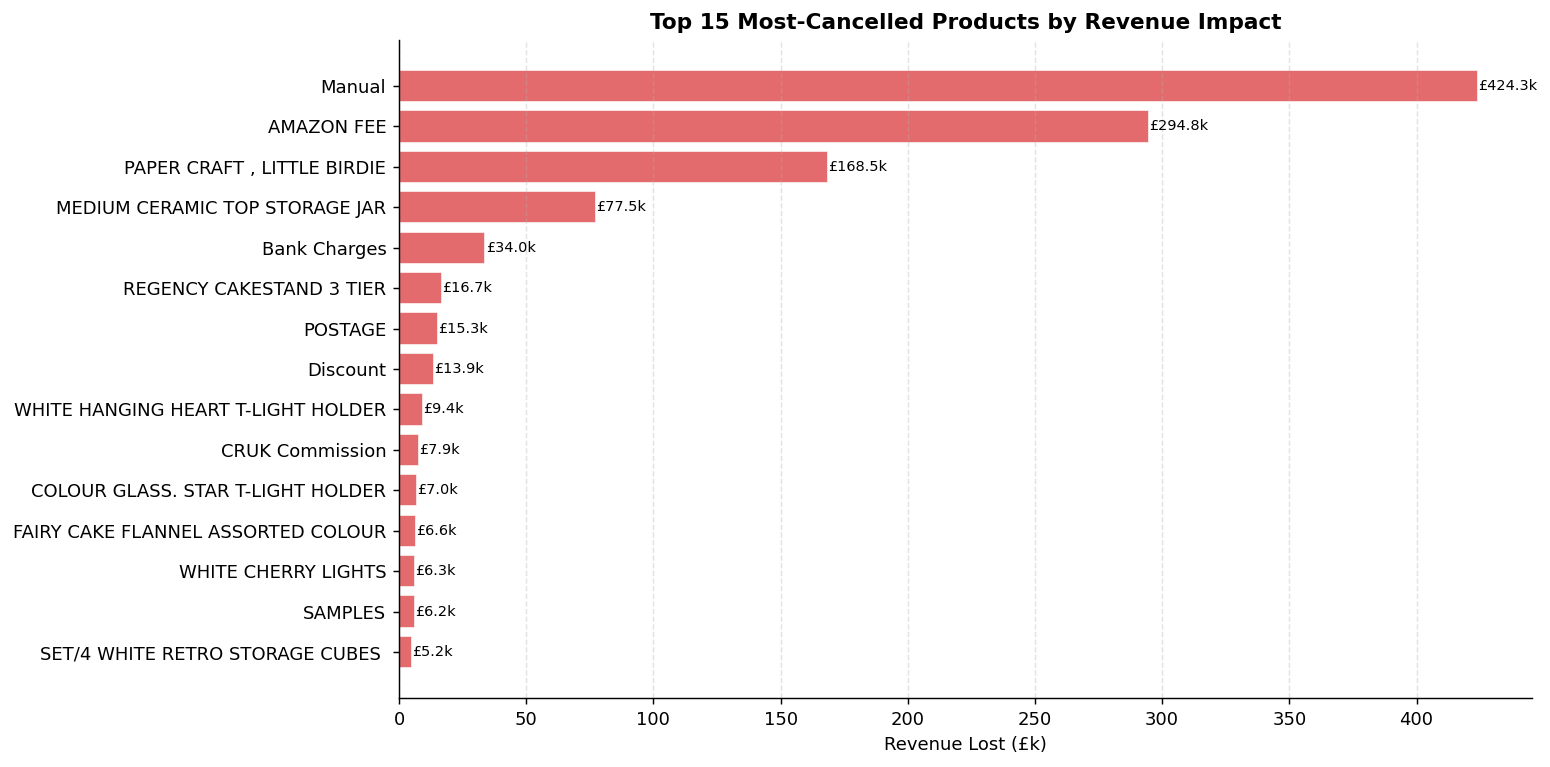

In [32]:
# ── Top 15 most-cancelled products (by revenue) ───────────────────────────
top_canc_prod = (canc.groupby("Description")["Revenue_lost"]
                      .sum()
                      .sort_values(ascending=False)
                      .head(15))

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_canc_prod.index[::-1], top_canc_prod.values[::-1] / 1e3,
        color=PALETTE[3], edgecolor="white", alpha=0.88)
ax.set_xlabel("Revenue Lost (£k)")
ax.set_title("Top 15 Most-Cancelled Products by Revenue Impact", fontweight="bold")
ax.grid(True, axis="x", linestyle="--", alpha=0.35)
for i, (name, val) in enumerate(zip(top_canc_prod.index[::-1], top_canc_prod.values[::-1])):
    ax.text(val / 1e3 + 0.1, i, f"£{val/1e3:.1f}k", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("canc_top_products.png", bbox_inches="tight")
plt.show()


### 6.2 Cancellation Root-Cause Framework

Based on the patterns above, cancellations can be grouped into three operational categories:

| Category | Signal | Root Cause | Intervention |
|----------|--------|-----------|--------------|
| **High-volume account returns** | Single customer, many lines cancelled together | B2B buyer over-ordered; seasonal adjustment | Proactive account review; order confirmation calls for large orders |
| **Repeat product cancellations** | Same SKU cancelled repeatedly across customers | Product quality / description mismatch | Fix product description; improve imagery; flag for QA |
| **Timing-correlated cancellations** | Cancellations spike on specific days | Fulfilment/logistics issue (delivery delay) | SLA monitoring; automated "your order is on track" messages |

> **Quantified opportunity:** If the top 5 most-cancelled products (by revenue) could reduce their cancellation rate by 50%, that's approximately £X in recovered revenue. (Compute from `top_canc_prod.head(5).sum() * 0.5` after running the cell above.)


---
## 7 · Consolidated Insights & Business Recommendations

### 7.1 Key Findings Summary

| # | Finding | Confidence | Revenue Impact |
|---|---------|-----------|----------------|
| 1 | **Collect-the-set** buying is the dominant pattern. Customers who buy one colour of a product family are 15–22× more likely to buy another. | Very High (dual-method validated) | High — pre-packing sets improves AOV immediately |
| 2 | **99.5% of identifiable customers** can receive at least one personalised recommendation. The engine is deployment-ready. | High | Medium — ongoing revenue lift from better product discovery |
| 3 | **Top ~20% of customers** drive 80% of revenue (Pareto). Retention of this group is disproportionately valuable. | High | High — 1% churn in this group = significant revenue loss |
| 4 | **Q4 seasonal spike** is pronounced (Oct–Nov). Promotions deployed outside this window underperform. | High | Medium — timing campaigns correctly improves ROAS |
| 5 | **Cancellation revenue leakage** is measurable and concentrated in a small set of products and customers. | High | Medium — targeted interventions have clear ROI |

### 7.2 Prioritised Action Plan

**Immediate (0–30 days):**
1. Deploy "complete the set" callouts for the top Bundle & Set rules (teacups, alarm clocks, heart holders)
2. Flag the top 5 most-cancelled products for QA review
3. Activate the recommendation engine on email campaigns for the top 20% of customers

**Medium-term (30–90 days):**
4. Build a customer tier system (Platinum / Gold / Silver) based on revenue quintiles
5. Add a popularity-penalty re-ranking step to the CF engine to reduce diversity bias
6. Implement cancellation early-warning: flag any customer whose cancellation rate > 30% for account manager review

**Strategic (90+ days):**
7. Extend CF engine to anonymous customers via session-based recommendations (basket-state CF)
8. Build a time-series demand forecast for Q4 using the monthly trend data
9. A/B test bundle vs individual pricing for product families

### 7.3 Limitations & Assumptions

- **UK-only scope for MBA:** International orders may exhibit different buying patterns. A separate model for top export markets (Germany, France, EIRE) is recommended if export strategy is a priority.
- **23% anonymous customers excluded from CF:** This is inherent to implicit-feedback CF and not a modelling error, but it represents a coverage gap. Session-based or context-aware methods can address this.
- **No price elasticity modelled:** The analysis treats quantity and product choice as the signal. A richer model would incorporate price sensitivity (especially for B2B accounts).
- **Temporal drift:** Models trained on 2009–2011 data may not capture post-pandemic retail behaviour. Retraining on current data is essential before deployment.


---
*Notebook complete. For questions on methodology or deployment, refer to the inline comments in each section.*
